# Preparação

Após ter criado o cluster e carregado os arquivos CSV para o Databricks chegou a hora de transforma-los em tabela.
Para isso execute a célula abaixo clicando nela e depois **ctrl + enter**

*Lembre-se de antes de usar esse notebook ativar o cluster, para isso uma vez que ele já tenha sido criado, basta clicar no botão "Detached" encontrado no canto esquerdo superior abaixo do título do notebook. Para mais informações olhe o tutorial em word*

In [ ]:
from sqlalchemy import text

with engine.connect() as conn:
    conn.execute(text("""CREATE TABLE fat_net_completo AS
SELECT
    -- fat_net_mensal
    n.COD_DIM_TEMPO,
    n.COD_DIM_CONTA,
    n.COD_DIM_PRODUTO,
    n.COD_DIM_CANAL_ASSESSOR,
    n.VAL_POSICAO,
    
    -- dim_canal_assessor (a)
    a.CANAL,
    
    -- dim_conta_suitability (s)
    s.SUITABILITY,
    
    -- dim_produto (p)
    p.CLASSE_N1,
    p.CLASSE_N2,
    
    -- fat_recomendacao (r)
    r.ALOCACAO_RECOMENDADA
                      
FROM fat_net_mensal n
JOIN dim_canal_assessor a 
    ON n.COD_DIM_CANAL_ASSESSOR = a.COD_DIM_CANAL_ASSESSOR
JOIN dim_conta_suitability s 
    ON n.COD_DIM_CONTA = s.COD_DIM_CONTA
JOIN dim_produto p 
    ON n.COD_DIM_PRODUTO = p.COD_DIM_PRODUTO
JOIN fat_recomendacao r 
    ON n.COD_DIM_TEMPO = r.COD_DIM_TEMPO 
    AND s.SUITABILITY = r.SUITABILITY 
    AND p.CLASSE_N1 = r.CLASSE_N1;

"""))


In [1]:
# Função para simular execução de querys ou comandos em SQL

from sqlalchemy import text
import pandas as pd

def executar_query(query, engine):
    comando = None
    try:
        comando = query.strip().lower()
        if comando.startswith("select") or comando.startswith("with"):
            df = pd.read_sql(query, con=engine)
            df
            return df
        else:
            with engine.connect() as conexao:
                comandos = query.strip().split(";")
                for cmd in comandos:
                    stmt = cmd.strip()
                    if stmt:
                        conexao.execute(text(stmt))
                conexao.commit()
                print("Comando(s) SQL executado(s) com sucesso.")
                return None
    except Exception as erro:
        
        print(f"Erro ao executar o SQL: {erro}")
        return None


In [2]:
from sqlalchemy import create_engine
import pandas as pd

# Leitura da base de dados 
df_assessor = pd.read_csv('dim_canal_assessor.csv', sep=';')
df_suitability = pd.read_csv('dim_conta_suitability.csv', sep=';')
df_produto = pd.read_csv('dim_produto.csv', sep=';')
df_net_mensal = pd.read_csv('fat_net_mensal.csv', sep=';')
df_recomendacao = pd.read_csv('fat_recomendacao.csv', sep=';')

In [3]:
# Criação de um BD para simulação
engine = create_engine('sqlite:///texteXP.db')

# Salva os DF como tabelas
df_assessor.to_sql('dim_canal_assessor', con=engine, if_exists='replace', index=False)
df_suitability.to_sql('dim_conta_suitability', con=engine, if_exists='replace', index=False)
df_produto.to_sql('dim_produto', con=engine, if_exists='replace', index=False)
df_net_mensal.to_sql('fat_net_mensal', con=engine, if_exists='replace', index=False)
df_recomendacao.to_sql('fat_recomendacao', con=engine, if_exists='replace', index=False)

90

In [4]:
query = 'SELECT * FROM fat_net_mensal LIMIT 5'

executar_query(query, engine) 


,COD_DIM_TEMPO,COD_DIM_CANAL_ASSESSOR,COD_DIM_PRODUTO,COD_DIM_CONTA,VAL_POSICAO
0,20210831,28,47,144,41304.72
1,20210831,28,35,144,24514.96
2,20210831,28,39,144,88908.01
3,20210930,28,10,144,42419.84
4,20210930,28,38,144,18148.95


In [ ]:
# Script original - Geração de tabelas

lista_nomes_tabela = [
    'fat_recomendacao',
    'fat_net_mensal',
    'dim_produto',
    'dim_conta_suitability',
    'dim_canal_assessor'
]

for nome_tabela in lista_nomes_tabela:
    # File location and type
    file_location = f"/FileStore/tables/{nome_tabela}.csv"
    file_type = "csv"

    # CSV options
    infer_schema = "true"
    first_row_is_header = "true"
    delimiter = ";"

    # The applied options are for CSV files. For other file types, these will be ignored.
    df = (
        spark.read.format(file_type)
            .option("inferSchema", infer_schema)
            .option("header", first_row_is_header)
            .option("sep", delimiter)
            .load(file_location)
    )

    try:
        spark.sql(f"""drop table {nome_tabela}""")
    except:
        pass
    
    (
        df.write
          .mode('overwrite')
          .option("overwriteSchema", "true")
          .saveAsTable(nome_tabela)
    )

# Introdução

Abaixo será descrito um case fictício do mundo XP, em paralelo vamos disponibilizar alguns passo a passo para quem não tem familiaridade com SQL ou python, mas sinta-se a vontade para resolver do seu jeito, o que disponibilizamos é apenas uma sugestão para tentar ajudar


**NENHUM DADO DISPONIBILIZADO É REAL**

Uma das áreas de negócio da XP é o B2B, onde empresas denominadas de escritórios de investimentos, fazem uma parceria com a XP para que seus clientes invistam através de nossa plataforma. Esses escritórios atendem nossos clientes com os assessores autônomos de invesmento, que ajudam as pessoas a investirem melhor. Depois de uma reunião com um dos gerentes da nossa área B2B, ficou claro que a carteira de muitos clientes estava desalinhada com as carteiras recomendadas para seu perfil e caso conseguíssemos reduzir esse desalinhamento, iriamos ajudar os clientes tornando suas carteiras mais seguras e rentáveis ao mesmo tempo que aumentaríamos nossa receita. Criamos então um projeto separado em 4 etapas para conseguirmos aumentar a aderência das carteiras de invesmento dos clientes dentro de seu suitability.


A primeira etapa foi criar uma tabela que lista o suitability e a custódia mensal dos clientes do B2B para cada estratégia diferente de produto.

**Notas:**
- Suitability é o perfil do investidor, pode ser conservador, moderado ou agressivo e representa o quanto de risco o cliente está disposto a assumir pelo retorno
- Custódia é o tanto de dinheiro dos clientes que está investido dentro da plataforma XP. Esse dinheiro não é da XP
- Estratégia de produto é um tipo de classificação de produto que assume as seguintes categorias: Prefixado, Pós-Fixado, Inflação, Multimercado, Renda Variável e Internacional
- Se o assessor de algum cliente é do B2B, então esse cliente também é considerado desse canal

**Dicionário SQL:**

Para esse exercício são necessárias usar as principais clausulas do SQL, além de joins e algumas funções de agregação, ebaixo disponibilizamos alguns links de documentação do SQL para tirar suas dúvidas.
- [Principais comandos SQL](https://support.microsoft.com/pt-br/office/acesso-sql-conceitos-b%C3%A1sicos-vocabul%C3%A1rio-e-sintaxe-444d0303-cde1-424e-9a74-e8dc3e460671)
- [Como usar Joins](https://www.devmedia.com.br/sql-join-entenda-como-funciona-o-retorno-dos-dados/31006)
- [Funções de agregação para serem usadas com group by](https://www.devmedia.com.br/sql-funcoes-de-agregacao/38463)

In [6]:
# Execução do script para gerar a tabela indicada originalmente

query = '''
CREATE TABLE IF NOT EXISTS fat_custodia_conta_mensal AS
SELECT
    fat.COD_DIM_TEMPO,
    conta.COD_DIM_CONTA,
    conta.SUITABILITY,
    prod.CLASSE_N1 AS ESTRATEGIA, -- O AS permite renomear o nome de colunas
    sum(fat.VAL_POSICAO) AS CUSTODIA -- Quando usamos o Group by, podemos agrupar as colunas com funções de agregação, como o sum(), max(), min() e etc...
FROM fat_net_mensal AS FAT

INNER JOIN dim_canal_assessor AS aai 
    ON aai.COD_DIM_CANAL_ASSESSOR = fat.COD_DIM_CANAL_ASSESSOR 

INNER JOIN dim_produto AS prod
    ON prod.COD_DIM_PRODUTO = fat.COD_DIM_PRODUTO
--
INNER JOIN dim_conta_suitability AS conta
    ON conta.COD_DIM_CONTA = fat.COD_DIM_CONTA
--
WHERE aai.CANAL = 'B2B' 
GROUP BY
    fat.COD_DIM_TEMPO,
    conta.COD_DIM_CONTA,
    conta.SUITABILITY,
    prod.CLASSE_N1
'''

executar_query(query, engine) 


Comando(s) SQL executado(s) com sucesso.


In [0]:
-- Essa primeira linha de código é responsável por dizer que abaixo dela será criada uma tabela usando uma query
-- Query é um código de consulta em banco de dados
create or replace table fat_custodia_conta_mensal as

-- Abaixo existe uma query que resolve esse primeiro problema, caso nunca tenha visto SQL, use esse código para te dar um norte
-- Os nomes de tabela podem ser diferentes dependendo de como você fez a criação delas e talvez seja necessário indicar também o banco de dados, por exemplo: nome_banco_dados.nome_tabela

-- NO SQL o SELECT é uma clausula que permite escolher quais colunas consultar
SELECT
    -- Embora o SELECT seja um dos primeiros comandos na ordem de escrita do código, pelo interpretador, é uma das últimas cláusulas a serem processadas
    fat.COD_DIM_TEMPO,
    conta.COD_DIM_CONTA,
    conta.SUITABILITY,
    prod.CLASSE_N1 AS ESTRATEGIA, -- O AS permite renomear o nome de colunas
    sum(fat.VAL_POSICAO) AS CUSTODIA -- Quando usamos o Group by, podemos agrupar as colunas com funções de agregação, como o sum(), max(), min() e etc...
FROM fat_net_mensal AS FAT -- Assim como usamos o AS para renomear colunas podemos renomear tabelas também, por isso na frente de algumas colunas têm fat., esse é o apelido da tabela
-- O join é uma cláusula que permite relacionar duas tabelas, é como se fosse o PROCV do excel e existem vários tipos de join, o PROCV seria o left join,
-- Nesse caso foi usado o INNER JOIN que relaciona duas tabelas mas trás como resultado apenas a intersecção entre as duas
INNER JOIN dim_canal_assessor AS aai -- As tabelas do join também podem receber um apelido, isso ajuda na hora de identificar de onde vem cada coluna
    ON aai.COD_DIM_CANAL_ASSESSOR = fat.COD_DIM_CANAL_ASSESSOR -- Para fazer o join é preciso indicar com exatidão quais são as chaves das duas tabelas
--
INNER JOIN dim_produto AS prod
    ON prod.COD_DIM_PRODUTO = fat.COD_DIM_PRODUTO
--
INNER JOIN dim_conta_suitability AS conta
    ON conta.COD_DIM_CONTA = fat.COD_DIM_CONTA
--
WHERE aai.CANAL = 'B2B' -- o Where permite filtrar a tabela, nesse caso foi filtrado o canal B2B, porém ele está entre apóstrofes porque é uma string, ou seja, um texto e para ser interpretado como tal, devem ser usados os apóstrofes
-- No fim o Group by fala para o interpretador quais colunas seram agrupadas, um ponto importante é que todas as colunas que aparecem no SELECT precisam estar no group by ou serem agregadas com um sum() por exemplo
GROUP BY
    fat.COD_DIM_TEMPO,
    conta.COD_DIM_CONTA,
    conta.SUITABILITY,
    prod.CLASSE_N1

Quando uma tabela é criada o resultado da query fica como "Query returned no results", não se preocupe, isso significa que a tabela foi criada com sucesso, você pode consulta-la após isso fazendo um select, como mostrado na célula a seguir

In [7]:
# -- -- Consultando a tabela que acabou de ser criada
# -- select * from fat_custodia_conta_mensal
query = '''
SELECT * FROM fat_custodia_conta_mensal LIMIT 5
'''
executar_query(query, engine)

,COD_DIM_TEMPO,COD_DIM_CONTA,SUITABILITY,ESTRATEGIA,CUSTODIA
0,20210831,13,Moderado,Renda Variável,215385.02
1,20210831,40,Conservador,Internacional,51676.24
2,20210831,40,Conservador,Pós-Fixado,66363.49
3,20210831,40,Conservador,Renda Variável,50362.14
4,20210831,81,Agressivo,Internacional,49798.66


**Entendendo melhor a nosso banco de dados**

As tabelas disponibilizadas para esse desafio como você pode perceber na query acima possuem dois prefixos diferentes, sendo eles; FAT_ e DIM_

* **FAT_**: São as tabelas fato, o que significa que são tabelas que guardam os fatos históricos de algum acontecimento. Então de forma periódica algumas informações podem se repetir
  
  Exemplo: Se estivéssemos falando de uma tabela fato de vendas por cliente, teríamos uma tabela onde cada linha seria o total de vendas de um cliente naquele dia, então o mesmo cliente poderá se repetir na tabela várias vezes, porque as vendas podem acontecer em vários dias diferentes.
  
* **DIM_**: São as tabelas dimensão, elas se relacionam com as tabelas fato e guardam informações sobre algo, geralmente são tabelas com menos linhas e mais colunas que as fato.

  Exemplo: Pegando o exemplo de vendas da fato explicada acima. Na fato a conta do cliente vai se repetir várias vezes por conta dos dias, então é mantido na tabela fato apenas o código do cliente e na tabela dimensão vão ter todas as informações sobre os clientes, por exemplo o nome, idade, profissão e etc... dessa forma essas informações de texto não vão se repetir na tabela fato tornando a tabela muito mais rápida e menor.
  
**O que são os COD_DIM?**

Você vai perceber que em nossas tabelas existem colunas com o nome COD_DIM_, essas colunas são códigos que são usados para se relacionar dimensões e fatos, então por exemplo a coluna COD_DIM_TEMPO da tabela DIM_TEMPO, também existe na tabela fato FAT_NET_MENSAL e é usada para levar informações sobre o tempo para a tabela fato, que por sua vez fica mais rápida por não ter dados de texto.

# Desafio 1

Usando a tabela gerada na primeira etapa com o nome de *fat_custodia_conta_mensal*, faça um agrupamento de tal forma que exiba a custódia mais recente do cliente independente da estratégia e em seguida crie uma coluna que exiba a alocação em cada estratégia de produto para cada cliente.

Alocação: % de custódia que o produto tem na carteira

**Talvez você precise utilizar subquery ou CTE nessa etapa:**
- Usar uma CTE: [Criação de CTE](https://docs.databricks.com/sql/language-manual/sql-ref-syntax-qry-select-cte.html)
- Usar uma sub-query [O que são Sub queries](https://www.devmedia.com.br/trabalhando-com-subqueries/40134#:~:text=Uma%20Subquery%20(tamb%C3%A9m%20conhecida%20como,ou%20imposs%C3%ADveis%20de%20serem%20feitas.)

**Nessa etapa Window function poderá te ajudar:**

Resumindo, as Window Functions são as funções de agregação que já estamos acostumados a usar com o group by, mas usadas com o auxilio do over(partition by), dessa forma a função de agregação será usada usando o agrupamento informado no partition by e dessa forma o group by não precisará ser usado e aplicado em toda a query mas sim apenas no cálculo para criação da coluna.
- [Clique aqui para mais detalhes sobre Window Functions?](https://towardsdatascience.com/a-guide-to-advanced-sql-window-functions-f63f2642cbf9)

Um exemplo de Window function para pegar a data máxima dentro de cada mês seria: max(data) over(partition by mês)

Layout de resultado esperado:

| COD_DIM_CONTA | SUITABILITY | ESTRATEGIA     | CUSTODIA  | ALOCACAO            |
|---------------|-------------|----------------|-----------|---------------------|
| 13            | Moderado    | Internacional  | 8478.79   | 0.04659281530774825 |
| 13            | Moderado    | Pós-Fixado     | 116706.06 | 0.6413254602219167  |
| 13            | Moderado    | Renda Variável | 56791.49  | 0.312081724470335   |

In [8]:
# ----- SUGESTÃO DE ORDEM DE RESOLUÇÃO: Não precisa ser seguida -------
# -- Usando uma CTE, consulte a tabela fat_custodia_conta_mensal criada na etapa acima e consiga a data mas recente de custódia do cliente naquela estratégia, uma dica é usar max() over(partiton by conta, tempo)

query = '''
WITH  
    TOTAL_CUSTODIA AS (
        SELECT 
            COD_DIM_CONTA,
            COD_DIM_TEMPO,
            SUM(CUSTODIA) AS TOTAL_EM_CUSTODIA,
            ROW_NUMBER() OVER (PARTITION BY COD_DIM_CONTA ORDER BY COD_DIM_TEMPO DESC) AS recente
        FROM fat_custodia_conta_mensal
        GROUP BY 
            COD_DIM_TEMPO, COD_DIM_CONTA
    ) 
    SELECT
        FCCM.COD_DIM_CONTA,
        FCCM.SUITABILITY,
        FCCM.ESTRATEGIA,
        FCCM.CUSTODIA, 
        (CUSTODIA / TOTAL_EM_CUSTODIA) AS ALOCACAO

    FROM fat_custodia_conta_mensal FCCM
    JOIN TOTAL_CUSTODIA TC on FCCM.COD_DIM_CONTA = TC.COD_DIM_CONTA AND FCCM.COD_DIM_TEMPO = TC.COD_DIM_TEMPO
    WHERE TC.recente = 1
'''

executar_query(query, engine) 

# -- Usando a CTE anterior, pode ser aplicada outra window function, mas dessa vez com sum(), para que seja possível coletar a custódia máxima daquele cliente naquela classe de ativo
# -- Dessa forma a custódia poderá ser dividida pela custódia total a calculada para chegarmos na alocação


,COD_DIM_CONTA,SUITABILITY,ESTRATEGIA,CUSTODIA,ALOCACAO
0,13,Moderado,Pós-Fixado,116706.06,0.672667
1,13,Moderado,Renda Variável,56791.49,0.327333
2,40,Conservador,Pós-Fixado,81623.50,0.414124
3,40,Conservador,Renda Variável,115475.60,0.585876
4,81,Agressivo,Internacional,21460.77,0.243695
5,81,Agressivo,Renda Variável,66603.36,0.756305
6,87,Agressivo,Pós-Fixado,163081.88,0.848470
7,87,Agressivo,Renda Variável,29125.03,0.151530
8,100,Conservador,Internacional,70229.62,0.399474
9,100,Conservador,Pós-Fixado,86527.75,0.492179


# Desafio 2

Calcule a diferença de alocação em cada estratégia de produto baseado na alocação recomendada pela tabela *FAT_RECOMENDACAO*. Essa nova coluna deve mostrar a diferença em pontos percentuais (valor absoluto) entre a carteira do cliente e a carteira recomendada. Após isso filtre os 5 clientes com maior diferença de alocação.

**Notas:**
- Para filtrar os 5 clientes com maior diferença de alocação é preciso descobrir a diferença de alocação total por cliente (desconsiderando a quebra de estratégia).
- Adote como premissa que vamos usar a recomendação mais recente da fat_recomendacao, você pode fazer isso filtrando a data máxima

Nessa etapa você precisará usar o resultado do exercício anterior, você têm algumas formas de fazer isso:
- Criar uma view permanente ou temporária do resultado anterior: [Criação de View](https://docs.databricks.com/spark/latest/spark-sql/language-manual/sql-ref-syntax-ddl-create-view.html)
- Criar uma tabela do resultado anterior: [Criação de tabela](https://docs.databricks.com/spark/latest/spark-sql/language-manual/sql-ref-syntax-ddl-create-table.html)
- Usar uma CTE: [Criação de CTE](https://docs.databricks.com/sql/language-manual/sql-ref-syntax-qry-select-cte.html)
- Usar uma sub-query [O que são Sub queries](https://www.devmedia.com.br/trabalhando-com-subqueries/40134#:~:text=Uma%20Subquery%20(tamb%C3%A9m%20conhecida%20como,ou%20imposs%C3%ADveis%20de%20serem%20feitas.)

Além de usar o resultado do exercício anterior, use a tabela fat_recomendacao disponibilizada para chegar ao resultado esperado, lembrando que a recomendação é feita para cada classe de ativo de acordo com o suitability e isso pode mudar todos os meses
- [Use a função limit para escolher 5 clientes com maior diferença de alocação, lembre-se antes de ordernar em ordem decrescente o desvio usando o order by](https://docs.databricks.com/sql/language-manual/sql-ref-syntax-qry-select-limit.html)
- [Para selecionar o valor absoluto de desvio use a função abs()](https://docs.databricks.com/sql/language-manual/functions/abs.html)

Layout de resultado esperado:

| COD_DIM_CONTA | SUITABILITY | ESTRATEGIA     | CUSTODIA | ALOCACAO            | ALOCACAO_RECOMENDADA | DESVIO_ALOCACAO     |
|---------------|-------------|----------------|----------|---------------------|----------------------|---------------------|
| 40            | Conservador | Internacional  | 51676.24 | 0.20772251783476608 | 0.1                  | 0.10772251783476608 |
| 40            | Conservador | Pós-Fixado     | 81623.5  | 0.32810124990684364 | 0.9                  | 0.5718987500931564  |
| 40            | Conservador | Renda Variável | 115475.6 | 0.4641762322583903  | 0                    | 0.4641762322583903  |

# Resposta - Desafio 2

Foi criada uma view temporária chamada alocacao_conta que agrupa a alocação relativa ao total por cod_dim_conta e cod_dim_tempo, gerando uma visão mensal da alocação de cada conta em cada estratégia.

A partir dessa base, foi selecionada a foto mensal mais recente de cada conta, junto com a recomendação mais atual, e criada uma view de suporte com o ranking das contas por soma do desvio acumulado por cliente (acúmulo de desvio por estratégia).

Essa view suporte permite identificar, por estratégia, as contas com os maiores desvios.

Observações importantes:

A base usada, fat_custodia_conta_mensal, contempla apenas contas B2B.

A base fat_custodia_conta_mensal contém apenas contas B2B, então nem todas as contas aparecem.

Não consideramos como desvio os casos em que a recomendação existe (ALOCACAO_RECOMENDADA > 0), mas o cliente não tem custódia nem alocação atual (custódia = 0, alocação = 0).

Nestes casos, o cliente ainda não executou a recomendação, portanto não há desvio.


| COD_DIM_CONTA | SUITABILITY | ESTRATEGIA     | CUSTODIA | ALOCACAO            | ALOCACAO_RECOMENDADA | DESVIO_ALOCACAO     |
|---------------|-------------|----------------|----------|---------------------|----------------------|---------------------|
| 40            | Conservador | Internacional  | 51676.24 | 0.20772251783476608 | 0.1                  | 0.10772251783476608 |
| 40            | Conservador | Pós-Fixado     | 81623.5  | 0.32810124990684364 | 0.8                  | 0.5718987500931564  |
| 40            | Conservador | Renda Variável | 0        | 0                   | 0.1                  | (não considerado)   |

Esse caso foi considerado posteriormente (no desafio 4)

In [9]:
# ----- SUGESTÃO DE ORDEM DE RESOLUÇÃO: Não precisa ser seguida -------
# -- Usando uma CTE, consulte a tabela fat_custodia_conta_mensal criada na etapa acima e consiga a data mas recente de custódia do cliente naquela estratégia, uma dica é usar max() over(partiton by conta, tempo)

query = '''
CREATE TEMP VIEW alocacao_conta as 

WITH  
    TOTAL_CUSTODIA AS (
        SELECT 
            COD_DIM_CONTA,
            COD_DIM_TEMPO,
            SUM(CUSTODIA) AS TOTAL_EM_CUSTODIA,
            ROW_NUMBER() OVER (PARTITION BY COD_DIM_CONTA ORDER BY COD_DIM_TEMPO DESC) AS recente
        FROM fat_custodia_conta_mensal
        GROUP BY 
            COD_DIM_TEMPO, COD_DIM_CONTA
    ) 
    SELECT
        FCCM.COD_DIM_CONTA,
        FCCM.SUITABILITY,
        FCCM.ESTRATEGIA,
        FCCM.CUSTODIA,
        TC.COD_DIM_TEMPO,
        (CUSTODIA / TOTAL_EM_CUSTODIA) AS ALOCACAO

    FROM fat_custodia_conta_mensal FCCM
    JOIN TOTAL_CUSTODIA TC on FCCM.COD_DIM_CONTA = TC.COD_DIM_CONTA AND FCCM.COD_DIM_TEMPO = TC.COD_DIM_TEMPO
    WHERE TC.recente = 1
'''

executar_query(query, engine) 


Comando(s) SQL executado(s) com sucesso.


In [10]:
query = '''
SELECT * FROM alocacao_conta LIMIT 5
'''

executar_query(query, engine) 


,COD_DIM_CONTA,SUITABILITY,ESTRATEGIA,CUSTODIA,COD_DIM_TEMPO,ALOCACAO
0,13,Moderado,Pós-Fixado,116706.06,20211031,0.672667
1,13,Moderado,Renda Variável,56791.49,20211031,0.327333
2,40,Conservador,Pós-Fixado,81623.50,20211031,0.414124
3,40,Conservador,Renda Variável,115475.60,20211031,0.585876
4,81,Agressivo,Internacional,21460.77,20211031,0.243695


In [11]:
## Criando uma temp view com o ranking de maiores desvio de alocações ao total (por conta, e não por estrategia)
query = '''
CREATE TEMP VIEW ranking_desvio_alocacao as 

WITH alocacao AS (
    SELECT
        COD_DIM_CONTA,
        COD_DIM_TEMPO,
        SUITABILITY,
        ESTRATEGIA,
        ALOCACAO
    FROM alocacao_conta
),
diferencas AS (
    SELECT
        a.COD_DIM_TEMPO,
        a.COD_DIM_CONTA,
        r.SUITABILITY,
        SUM(ABS(a.ALOCACAO - r.ALOCACAO_RECOMENDADA)) AS DIFERENCA_ALOCADA
    FROM fat_net_mensal n
    JOIN alocacao a
        ON n.COD_DIM_TEMPO = a.COD_DIM_TEMPO 
        AND n.COD_DIM_CONTA = a.COD_DIM_CONTA 
    JOIN fat_recomendacao r 
        ON a.COD_DIM_TEMPO = r.COD_DIM_TEMPO 
        AND a.SUITABILITY = r.SUITABILITY 
        AND a.ESTRATEGIA = r.CLASSE_N1
    GROUP BY a.COD_DIM_TEMPO, a.COD_DIM_CONTA, r.SUITABILITY
)
SELECT
    *,
    RANK() OVER (ORDER BY DIFERENCA_ALOCADA DESC) AS RANK_DIFERENCA
FROM diferencas
ORDER BY RANK_DIFERENCA;
'''

executar_query(query, engine) 


Comando(s) SQL executado(s) com sucesso.


In [12]:
## Exibindo as top 5 contas com maiores desvios, lembrando que aqui não consta todos os clientes nem todos desvios
## Isso acontece porque nem todo cliente está na base 

query = '''
WITH 
    alocacao AS (
        SELECT
            COD_DIM_CONTA,
            COD_DIM_TEMPO,
            SUITABILITY,
            ESTRATEGIA,
            ALOCACAO
        FROM alocacao_conta
    ), 

    desvio_alocacao AS (
    SELECT 
    COD_DIM_CONTA,
    RANK_DIFERENCA
    FROM ranking_desvio_alocacao
    )

SELECT
    DISTINCT
    a.COD_DIM_TEMPO,
    a.COD_DIM_CONTA,
    r.SUITABILITY,
    a.ESTRATEGIA,
    a.ALOCACAO,
    r.ALOCACAO_RECOMENDADA,
    ABS(ALOCACAO_RECOMENDADA - ALOCACAO) AS DIFERENCA_ALOCADA,
    da.RANK_DIFERENCA

FROM fat_net_mensal n

JOIN alocacao a
    ON n.COD_DIM_TEMPO = a.COD_DIM_TEMPO 
    AND a.COD_DIM_CONTA = a.COD_DIM_CONTA 
JOIN fat_recomendacao r 
    ON a.COD_DIM_TEMPO = r.COD_DIM_TEMPO 
    AND a.SUITABILITY = r.SUITABILITY 
    AND a.ESTRATEGIA = r.CLASSE_N1
    
JOIN desvio_alocacao da
    ON a.COD_DIM_CONTA = da.COD_DIM_CONTA

WHERE RANK_DIFERENCA <= 5
'''

executar_query(query, engine) 


,COD_DIM_TEMPO,COD_DIM_CONTA,SUITABILITY,ESTRATEGIA,ALOCACAO,ALOCACAO_RECOMENDADA,DIFERENCA_ALOCADA,RANK_DIFERENCA
0,20211031,40,Conservador,Pós-Fixado,0.414124,0.90,0.485876,1
1,20211031,40,Conservador,Renda Variável,0.585876,0.00,0.585876,1
2,20211031,128,Moderado,Renda Variável,1.000000,0.10,0.900000,2
3,20211031,87,Agressivo,Pós-Fixado,0.848470,0.29,0.558470,3
4,20211031,87,Agressivo,Renda Variável,0.151530,0.42,0.268470,3
5,20211031,100,Conservador,Internacional,0.399474,0.10,0.299474,4
6,20211031,100,Conservador,Pós-Fixado,0.492179,0.90,0.407821,4
7,20211031,100,Conservador,Renda Variável,0.108347,0.00,0.108347,4
8,20211031,135,Conservador,Internacional,0.306717,0.10,0.206717,5
9,20211031,135,Conservador,Pós-Fixado,0.693283,0.90,0.206717,5


# Desafio 3

Bem agora que você construíu os dados de alocação recomendada e sabe melhor como está a carteira dos clientes, quais seriam os próximos passos? Sinta-se a vontade para usar todas as tabelas disponibilizadas até então.

Além disso o time de produtos te disponibilizou uma tabela com o ROA médio para cada estratégia de produto. Essa tabela pode ser acessada com o nome de *TB_ROA_MEDIO*

**Notas:**
- ROA = Revenue Over Assets = Receita / Custódia
- Receita = Dinheiro que a XP ganha com taxas, ou operações do cliente
- Custódia = Dinheiro dos clientes que está investido dentro da plataforma XP

---

## Desenvolvimento - Desafio 3

Dentro desse desafio, foi explorado por meio do SQL algumas relações das variáveis existente com o ROA, sendo possível entender as receitas por produto, cliente, assessor, suitability e estratégia. 

Em primeiro, foi criado uma base com o ROA de cada alocação por conta, mês e estratégia. 

Em seguida, foram analisados os agrupamentos apontaos acima. 

In [ ]:
%python
"""
Não se preocupe com esse código, aqui está sendo criada a tabela: TB_ROA_MEDIO
Caso queira fique a vontade para usar essa tabela

Outro detalhe é que estamos usando python para cria-la, o Databricks dá essa flexibilidade, baita ferramenta não? rs'
"""
# Importando biblioteca do python com algumas funções uteis
import pandas as pd

# Criando tabela de ROA Médio usando o pandas
roa_medio = pd.DataFrame(
    {'ESTRATEGIA':['Internacional',
                  'Pós-Fixado',
                  'Renda Variável'],
    'ROA_MEDIO':[0.009,
                 0.003,
                 0.01]
    }
)

# Convertendo a tabela do pandas para tabela em banco de dados para que possa ser consultada com SQL
(
    spark.createDataFrame(roa_medio) # Criando dataframe do spark com base na tabela do Pandas
        .write.mode('overwrite') # Definindo método de salvamento da tabela para subscrever possíveis dados já carregados
        .option("overwriteSchema", "true") # Definindo opção de ingestão para que a estrutura da tabela seja substituída pela atual
        .saveAsTable('TB_ROA_MEDIO') # Criando de fato uma tabela no banco de dados com o nome de TB_ROA_MEDIO
) 

In [16]:
# Criação base ROA_MEDIO no banco de dados.

roa_medio = pd.DataFrame(
    {'ESTRATEGIA':['Internacional',
                  'Pós-Fixado',
                  'Renda Variável'],
    'ROA_MEDIO':[0.009,
                 0.003,
                 0.01]
    }
)

roa_medio.to_sql('roa_medio', con=engine, if_exists='replace', index=False )


query = '''
select * from roa_medio
'''

executar_query(query, engine) 

,ESTRATEGIA,ROA_MEDIO
0,Internacional,0.009
1,Pós-Fixado,0.003
2,Renda Variável,0.010


In [17]:
# Criação de uma tabela geral (semelhante a fat_custodia_conta_mensal) porém sem filtro de canal

query = '''
CREATE TABLE IF NOT EXISTS fat_custodia AS
SELECT
    fat.COD_DIM_TEMPO,
    conta.COD_DIM_CONTA,
    fat.COD_DIM_CANAL_ASSESSOR,
    aai.CANAL,
    conta.SUITABILITY,
    prod.CLASSE_N1 AS ESTRATEGIA, -- O AS permite renomear o nome de colunas
    sum(fat.VAL_POSICAO) AS CUSTODIA, -- Quando usamos o Group by, podemos agrupar as colunas com funções de agregação, como o sum(), max(), min() e etc...
    rec.ALOCACAO_RECOMENDADA
FROM fat_net_mensal AS FAT

INNER JOIN dim_canal_assessor AS aai 
    ON aai.COD_DIM_CANAL_ASSESSOR = fat.COD_DIM_CANAL_ASSESSOR 

INNER JOIN dim_produto AS prod
    ON prod.COD_DIM_PRODUTO = fat.COD_DIM_PRODUTO
--
INNER JOIN dim_conta_suitability AS conta
    ON conta.COD_DIM_CONTA = fat.COD_DIM_CONTA
--
JOIN fat_recomendacao AS rec 
    ON fat.COD_DIM_TEMPO = rec.COD_DIM_TEMPO 
    AND conta.SUITABILITY = rec.SUITABILITY 
    AND prod.CLASSE_N1 = rec.CLASSE_N1

GROUP BY
    fat.COD_DIM_TEMPO,
    conta.COD_DIM_CONTA,
    conta.SUITABILITY,
    prod.CLASSE_N1,
    rec.ALOCACAO_RECOMENDADA
'''

executar_query(query, engine) 



Comando(s) SQL executado(s) com sucesso.


In [18]:
query = '''
select * from fat_custodia limit 5;
'''

executar_query(query, engine) 



,COD_DIM_TEMPO,COD_DIM_CONTA,COD_DIM_CANAL_ASSESSOR,CANAL,SUITABILITY,ESTRATEGIA,CUSTODIA,ALOCACAO_RECOMENDADA
0,20210831,13,53,B2B,Moderado,Renda Variável,215385.02,0.19
1,20210831,15,9,B2C,Moderado,Pós-Fixado,81397.41,0.73
2,20210831,15,9,B2C,Moderado,Renda Variável,121770.77,0.19
3,20210831,23,45,B2C,Agressivo,Internacional,63500.90,0.28
4,20210831,23,45,B2C,Agressivo,Pós-Fixado,65562.43,0.29


In [19]:
# Criação de uma base de dados com o ROA Individual de cada aplicação por estratégia e mês

query = '''
CREATE TABLE IF NOT EXISTS receita_individual AS
WITH 
    TOTAL_CUSTODIA AS (
        SELECT 
            COD_DIM_CONTA,
            COD_DIM_TEMPO,
            SUM(CUSTODIA) AS TOTAL_EM_CUSTODIA
        FROM fat_custodia
        GROUP BY 
            COD_DIM_TEMPO, COD_DIM_CONTA
    )

    SELECT
        FC.COD_DIM_CONTA,
        FC.COD_DIM_TEMPO,
        FC.CANAL,
        FC.SUITABILITY,
        FC.ESTRATEGIA,
        FC.CUSTODIA, 
        FC.ALOCACAO_RECOMENDADA,
        (CUSTODIA / TOTAL_EM_CUSTODIA) AS ALOCACAO,
        ROA_MEDIO * FC.CUSTODIA AS RECEITA
        
    FROM fat_custodia FC
    JOIN TOTAL_CUSTODIA TC on FC.COD_DIM_CONTA = TC.COD_DIM_CONTA AND FC.COD_DIM_TEMPO = TC.COD_DIM_TEMPO
    JOIN roa_medio RM on FC.ESTRATEGIA = RM.ESTRATEGIA
    ORDER BY FC.COD_DIM_CONTA, FC.COD_DIM_TEMPO DESC
'''

executar_query(query, engine) 

# -- Query (código) completa do último exercício


Comando(s) SQL executado(s) com sucesso.


In [20]:
# Base criada RECEITA_individual

query = '''
SELECT 
    *
FROM receita_individual 
LIMIT 5 
'''
executar_query(query, engine) 


,COD_DIM_CONTA,COD_DIM_TEMPO,CANAL,SUITABILITY,ESTRATEGIA,CUSTODIA,ALOCACAO_RECOMENDADA,ALOCACAO,RECEITA
0,13,20211031,B2B,Moderado,Pós-Fixado,116706.06,0.80,0.672667,350.11818
1,13,20211031,B2B,Moderado,Renda Variável,56791.49,0.10,0.327333,567.91490
2,13,20210930,B2B,Moderado,Internacional,8478.79,0.17,0.090504,76.30911
3,13,20210930,B2B,Moderado,Pós-Fixado,85205.41,0.66,0.909496,255.61623
4,13,20210831,B2B,Moderado,Renda Variável,215385.02,0.19,1.000000,2153.85020


---

## Resposta - Desafio 3


In [21]:
# TOP 5 ASSESORES COM MAIOR MEDIA DE RECEITA MENSAL

query = '''
SELECT 
    COD_DIM_CONTA, 
    COD_DIM_TEMPO,
    SUITABILITY,
    CANAL,
    SUM(RECEITA) AS RECEITA_ACUMULADO_MENSAL,
    AVG(RECEITA) AS RECEITA_MEDIA,
    COUNT(RECEITA) AS QUANTIDADE_CLIENTES
FROM RECEITA_INDIVIDUAL 
GROUP BY COD_DIM_CONTA, COD_DIM_TEMPO
ORDER BY RECEITA_MEDIA DESC
LIMIT 5 
'''
executar_query(query, engine) 


,COD_DIM_CONTA,COD_DIM_TEMPO,SUITABILITY,CANAL,RECEITA_ACUMULADO_MENSAL,RECEITA_MEDIA,QUANTIDADE_CLIENTES
0,13,20210831,Moderado,B2B,2153.85020,2153.85020,1
1,74,20211031,Agressivo,B2C,1991.59308,1991.59308,1
2,128,20211031,Moderado,B2B,1696.22050,1696.22050,1
3,135,20210831,Conservador,B2B,1689.68830,1689.68830,1
4,102,20211031,Agressivo,B2C,1093.23120,1093.23120,1


In [22]:
# TOP 5 CONTAS COM MAIOR RECEITA MENSAL

query = '''
SELECT 
    COD_DIM_CONTA, 
    COD_DIM_TEMPO,
    SUITABILITY,
    SUM(RECEITA) AS RECEITA_ACUMULADO_MENSAL
FROM RECEITA_INDIVIDUAL 
GROUP BY COD_DIM_CONTA, COD_DIM_TEMPO
ORDER BY RECEITA_ACUMULADO_MENSAL DESC
LIMIT 5 
'''
executar_query(query, engine) 


,COD_DIM_CONTA,COD_DIM_TEMPO,SUITABILITY,RECEITA_ACUMULADO_MENSAL
0,13,20210831,Moderado,2153.85020
1,74,20211031,Agressivo,1991.59308
2,124,20210930,Conservador,1828.88883
3,128,20211031,Moderado,1696.22050
4,135,20210831,Conservador,1689.68830


In [23]:
# Soma e RECEITA MEDIA por CANAL  

query = '''
SELECT 
    CANAL,
    SUM(RECEITA) AS RECEITA_ACUMULADO,
    AVG(RECEITA) AS RECEITA_MEDIA,
    COUNT(RECEITA) AS QUANTIDADE
FROM RECEITA_INDIVIDUAL 
GROUP BY CANAL
ORDER BY QUANTIDADE DESC
LIMIT 5 
'''
executar_query(query, engine) 


,CANAL,RECEITA_ACUMULADO,RECEITA_MEDIA,QUANTIDADE
0,B2C,29740.75914,561.146399,53
1,B2B,23828.49144,529.522032,45


In [24]:
# RECEITA por Suitability
query = '''
SELECT 
    SUITABILITY,
    SUM(RECEITA) AS RECEITA_ACUMULADO,
    AVG(RECEITA) AS RECEITA_MEDIA,
    COUNT(RECEITA) AS QUANTIDADE
FROM RECEITA_INDIVIDUAL
GROUP BY SUITABILITY 
ORDER BY RECEITA_ACUMULADO DESC
LIMIT 5 
'''
executar_query(query, engine) 


,SUITABILITY,RECEITA_ACUMULADO,RECEITA_MEDIA,QUANTIDADE
0,Agressivo,20543.87652,540.628329,38
1,Moderado,18195.46226,568.608196,32
2,Conservador,14829.91180,529.639707,28


In [ ]:
# RECEITA por Suitability
query = '''
'''
executar_query(query, engine) 


,COD_DIM_TEMPO,COD_DIM_CONTA,SUITABILITY,CUSTODIA
0,20210831,13,Moderado,215385.02
1,20210831,15,Moderado,203168.18
2,20210831,23,Agressivo,129063.33
3,20210831,40,Conservador,168401.87
4,20210831,74,Agressivo,160486.50
5,20210831,81,Agressivo,102852.55
6,20210831,87,Agressivo,246738.30
7,20210831,99,Moderado,164939.67
8,20210831,100,Conservador,197995.22
9,20210831,102,Agressivo,237310.37


In [ ]:
# Custodia por Suitability
query = '''
SELECT 
    AVG(CUSTODIA), 
    SUITABILITY 
    FROM 
    (SELECT COD_DIM_TEMPO, COD_DIM_CONTA, SUITABILITY, SUM(CUSTODIA) AS CUSTODIA FROM RECEITA_INDIVIDUAL GROUP BY COD_DIM_TEMPO, COD_DIM_CONTA, SUITABILITY) 
    WHERE CUSTODIA >= 0
    GROUP BY SUITABILITY
    
'''
executar_query(query, engine) 


,AVG(CUSTODIA),SUITABILITY
0,164449.498333,Agressivo
1,149058.242143,Conservador
2,156373.472353,Moderado


# Desafio 4 (Opcional)

**Sugestões de evolução:**

Sinta-se a vontade para fazer qualquer uma das sugestões ou ainda qualquer outra ideia que você tiver, use a criatividade e mostre seus conhecimentos técnicos, lembre-se que aqui no databricks você pode usar não só o SQL mas também o Python ou R caso você tenha conhecimento sob essas linguagens.

Algumas sugestões:
- Calcular a receita potencial gerada com a alocação recomendada dos clientes, ou seja, hoje os clientes possuem um desvio para a alocação recomendada, se esses clientes vendessem seus ativos e comprassem outros quanto de receita ele geraria para a XP? Você pode usar a tabela de ROA médio por estratégia de produto para fazer esse cálculo
- Analisar quais eram os clientes com maior custódia total por suitability
- Analisar os produtos com maior alocação dos clientes dentro do canal B2C
- Analisar o histórico de distribuição de produtos do cliente com os maiores desvios atualmente
- Plottar alguns gráficos usando o databricks ou o python
- Fazer uma projeção de custódia total do canal B2B e B2C

In [132]:
query = '''
WITH 
-- CTE com a soma de custódia por conta e tempo, marcando o mais recente
TOTAL_CUSTODIA AS (
    SELECT 
        COD_DIM_CONTA,
        COD_DIM_TEMPO,
        COD_DIM_CANAL_ASSESSOR,
        CANAL,
        SUM(CUSTODIA) AS TOTAL_EM_CUSTODIA,
        ROW_NUMBER() OVER (PARTITION BY COD_DIM_CONTA ORDER BY COD_DIM_TEMPO DESC) AS recente
    FROM fat_custodia
    GROUP BY COD_DIM_TEMPO, COD_DIM_CONTA
),

-- Custódia mais recente com alocação percentual
CUSTODIA_ATUAL AS (
    SELECT
        FCCM.COD_DIM_CONTA,
        FCCM.SUITABILITY,
        FCCM.ESTRATEGIA,
        FCCM.CUSTODIA,
        TC.COD_DIM_TEMPO,
        CASE 
            WHEN TC.TOTAL_EM_CUSTODIA = 0 THEN 0
            ELSE FCCM.CUSTODIA / TC.TOTAL_EM_CUSTODIA
        END AS ALOCACAO
    FROM fat_custodia FCCM
    JOIN TOTAL_CUSTODIA TC 
        ON FCCM.COD_DIM_CONTA = TC.COD_DIM_CONTA 
        AND FCCM.COD_DIM_TEMPO = TC.COD_DIM_TEMPO
),

-- Traz todas as combinações possíveis de: conta x suitability x estrategia)
RECOMENDACAO_EXPANDIDA AS (
    SELECT 
        DISTINCT
        CA.COD_DIM_CONTA,
        CA.COD_DIM_CANAL_ASSESSOR,
        CA.CANAL,
        R.COD_DIM_TEMPO,
        R.SUITABILITY,
        R.CLASSE_N1 AS ESTRATEGIA,
        R.ALOCACAO_RECOMENDADA
    FROM fat_recomendacao R
    -- Junta com todas as contas que têm a mesma suitability
    LEFT JOIN fat_custodia CA 
        ON R.SUITABILITY = CA.SUITABILITY
    WHERE R.COD_DIM_TEMPO IN (20211031, 20210930, 20210831)
),

RESULTADO AS (
    SELECT
        RE.COD_DIM_CONTA,
        RE.COD_DIM_TEMPO,
        RE.COD_DIM_CANAL_ASSESSOR,
        DCA.CANAL,
        RE.SUITABILITY,
        RE.ESTRATEGIA,
        COALESCE(CA.CUSTODIA, -1) AS CUSTODIA,
        COALESCE(CA.ALOCACAO, 0) AS ALOCACAO,
        RE.ALOCACAO_RECOMENDADA,
        ROW_NUMBER() OVER (
            PARTITION BY RE.COD_DIM_CONTA, RE.COD_DIM_TEMPO, RE.ESTRATEGIA
            ORDER BY CASE WHEN DCA.CANAL = 'B2B' THEN 0 ELSE 1 END
        ) AS rn
    FROM RECOMENDACAO_EXPANDIDA RE
    LEFT JOIN CUSTODIA_ATUAL CA
        ON RE.COD_DIM_CONTA = CA.COD_DIM_CONTA
        AND RE.ESTRATEGIA = CA.ESTRATEGIA
        AND RE.COD_DIM_TEMPO = CA.COD_DIM_TEMPO
        AND RE.SUITABILITY = CA.SUITABILITY
    JOIN dim_canal_assessor DCA
        ON RE.COD_DIM_CANAL_ASSESSOR = DCA.COD_DIM_CANAL_ASSESSOR
)

SELECT *
FROM RESULTADO
WHERE rn = 1
ORDER BY COD_DIM_CONTA, COD_DIM_TEMPO, ESTRATEGIA;

'''
df = executar_query(query, engine) 
executar_query(query, engine) 


,COD_DIM_CONTA,COD_DIM_TEMPO,COD_DIM_CANAL_ASSESSOR,CANAL,SUITABILITY,ESTRATEGIA,CUSTODIA,ALOCACAO,ALOCACAO_RECOMENDADA,rn
0,13,20210831,53,B2B,Moderado,Internacional,-1.00,0.000000,0.08,1
1,13,20210831,53,B2B,Moderado,Pós-Fixado,-1.00,0.000000,0.73,1
2,13,20210831,53,B2B,Moderado,Renda Variável,215385.02,1.000000,0.19,1
3,13,20210930,53,B2B,Moderado,Internacional,8478.79,0.090504,0.17,1
4,13,20210930,53,B2B,Moderado,Pós-Fixado,85205.41,0.909496,0.66,1
...,...,...,...,...,...,...,...,...,...,...
148,144,20210930,28,B2B,Moderado,Pós-Fixado,69194.93,0.619944,0.66,1
149,144,20210930,28,B2B,Moderado,Renda Variável,42419.84,0.380056,0.17,1
150,144,20211031,28,B2B,Moderado,Internacional,-1.00,0.000000,0.10,1
151,144,20211031,28,B2B,Moderado,Pós-Fixado,110794.39,0.893038,0.80,1


In [133]:
df['COD_DIM_TEMPO'] = pd.to_datetime(df['COD_DIM_TEMPO'].astype(str), format='%Y%m%d')
df['DESVIO_ABS'] = abs(df['ALOCACAO'] - df['ALOCACAO_RECOMENDADA'])

custodia_total_tempo = df.groupby(['COD_DIM_TEMPO', 'COD_DIM_CONTA'])['CUSTODIA'].sum().reset_index()
custodia_total_tempo = custodia_total_tempo.rename(columns={'CUSTODIA': 'CUSTODIA_TOTAL_TEMPO'})

df = df.merge(custodia_total_tempo, on=['COD_DIM_TEMPO','COD_DIM_CONTA'], how='left')

roa_medio = pd.DataFrame({
    'ESTRATEGIA': ['Internacional', 'Pós-Fixado', 'Renda Variável'],
    'ROA_MEDIO': [0.009, 0.003, 0.01]
})
df = df.merge(roa_medio, on='ESTRATEGIA', how='left')

df['RECEITA_ATUAL'] = df['CUSTODIA_TOTAL_TEMPO'] * df['ALOCACAO'] * df['ROA_MEDIO']
df['RECEITA_POTENCIAL'] = df['CUSTODIA_TOTAL_TEMPO'] * df['ALOCACAO_RECOMENDADA'] * df['ROA_MEDIO']


df

,COD_DIM_CONTA,COD_DIM_TEMPO,COD_DIM_CANAL_ASSESSOR,CANAL,SUITABILITY,ESTRATEGIA,CUSTODIA,ALOCACAO,ALOCACAO_RECOMENDADA,rn,DESVIO_ABS,CUSTODIA_TOTAL_TEMPO,ROA_MEDIO,RECEITA_ATUAL,RECEITA_POTENCIAL
0,13,2021-08-31,53,B2B,Moderado,Internacional,-1.00,0.000000,0.08,1,0.080000,215383.02,0.009,0.000000,155.075774
1,13,2021-08-31,53,B2B,Moderado,Pós-Fixado,-1.00,0.000000,0.73,1,0.730000,215383.02,0.003,0.000000,471.688814
2,13,2021-08-31,53,B2B,Moderado,Renda Variável,215385.02,1.000000,0.19,1,0.810000,215383.02,0.010,2153.830200,409.227738
3,13,2021-09-30,53,B2B,Moderado,Internacional,8478.79,0.090504,0.17,1,0.079496,93683.20,0.009,76.308295,143.335296
4,13,2021-09-30,53,B2B,Moderado,Pós-Fixado,85205.41,0.909496,0.66,1,0.249496,93683.20,0.003,255.613502,185.492736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,144,2021-09-30,28,B2B,Moderado,Pós-Fixado,69194.93,0.619944,0.66,1,0.040056,111613.77,0.003,207.582930,220.995265
149,144,2021-09-30,28,B2B,Moderado,Renda Variável,42419.84,0.380056,0.17,1,0.210056,111613.77,0.010,424.194599,189.743409
150,144,2021-10-31,28,B2B,Moderado,Internacional,-1.00,0.000000,0.10,1,0.100000,124063.59,0.009,0.000000,111.657231
151,144,2021-10-31,28,B2B,Moderado,Pós-Fixado,110794.39,0.893038,0.80,1,0.093038,124063.59,0.003,332.380491,297.752616


In [134]:
### Imports de bibliotecas 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np


# Configurações visuais
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

---

## Desafio 4 - Insights mais relevantes:


---

### Insight 1. Estratégias esquecidas (Estratégias recomendadas, que não tiveram recomendação)

Nosso principal objetivo deve ser alinhar os clientes às estratégias compatíveis com seus perfis de suitability, garantindo que suas carteiras estejam estruturadas para cumprir a função esperada: proteger, preservar ou expandir o patrimônio.

No entanto, ao analisarmos as alocações atuais, observamos que algumas estratégias de alto potencial têm sido subexploradas, mesmo quando são historicamente associadas a melhores retornos para a casa.

Outro ponto de atenção: cinco clientes com perfil conservador não possuem nenhuma exposição em pós-fixado, o que pode indicar uma alocação desalinhada com o perfil mais indicado para esse tipo de investidor.

Esse desalinhamento pode comprometer tanto a experiência do cliente quanto a eficiência da alocação estratégica da casa. É fundamental revisar essas posições e reforçar o direcionamento dos assessores com base em orientações consistentes com o perfil de suitability.

In [135]:
# Quais estratégias estão sendo ignoradas?

(df[(df['ALOCACAO_RECOMENDADA'] > 0) & (df['ALOCACAO'] <= 0)]
 .groupby(['SUITABILITY', 'ESTRATEGIA'])
 .size()
 .sort_values(ascending=False))


SUITABILITY  ESTRATEGIA    
Moderado     Internacional     13
Agressivo    Internacional      9
Conservador  Pós-Fixado         5
Agressivo    Pós-Fixado         5
Moderado     Renda Variável     5
Conservador  Internacional      4
Moderado     Pós-Fixado         4
Agressivo    Renda Variável     2
dtype: int64

---

### Insight 2 - Desvio de alocação e comparação de receita atual vs receita potencial.

Ao compararmos a receita atual vs. receita potencial, notamos:

O segmento B2B tende a ter maior eficiência (ou menor gap) entre receita realizada e potencial.

À primeira vista, quanto maior o desvio de alocação, maior a receita, mas a média nos conta outra história:

Embora de fato, quanto maior o desvio, maior a receita atual, quando analisamos a média do desvio alocado e a média de alocação temos o seguinte resultado

Transcrevendo o gráfico 2 em tabela:

| Suitability | Média de Alocação (Mensal) | Média de Desvio de Alocação     |
|---------------|-------------|----------------|
| Conservador   | R$  149.058 | 39,87%  | 
| Moderado   | R$ 156.373 | 29,47%     | 
| Agressivo      | R$  164.449 | 23,73% | 

Clientes com maior alinhamento entre carteira e suitability tendem a alocar mais recursos, sugerindo maior confiança na estrutura de recomendação. Desvios excessivos, embora pontualmente rentáveis, podem representar riscos de longo prazo tanto para o cliente quanto para a estratégia da instituição

C:\Users\lucas.souza\AppData\Local\Temp\ipykernel_10188\2708361827.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CANAL', y='DELTA_RECEITA', data=delta_receita_canal, ax=axs[1, 0], palette='viridis')
C:\Users\lucas.souza\AppData\Local\Temp\ipykernel_10188\2708361827.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SUITABILITY', y='DELTA_RECEITA', data=delta_receita_suit, ax=axs[1, 1], palette='viridis')


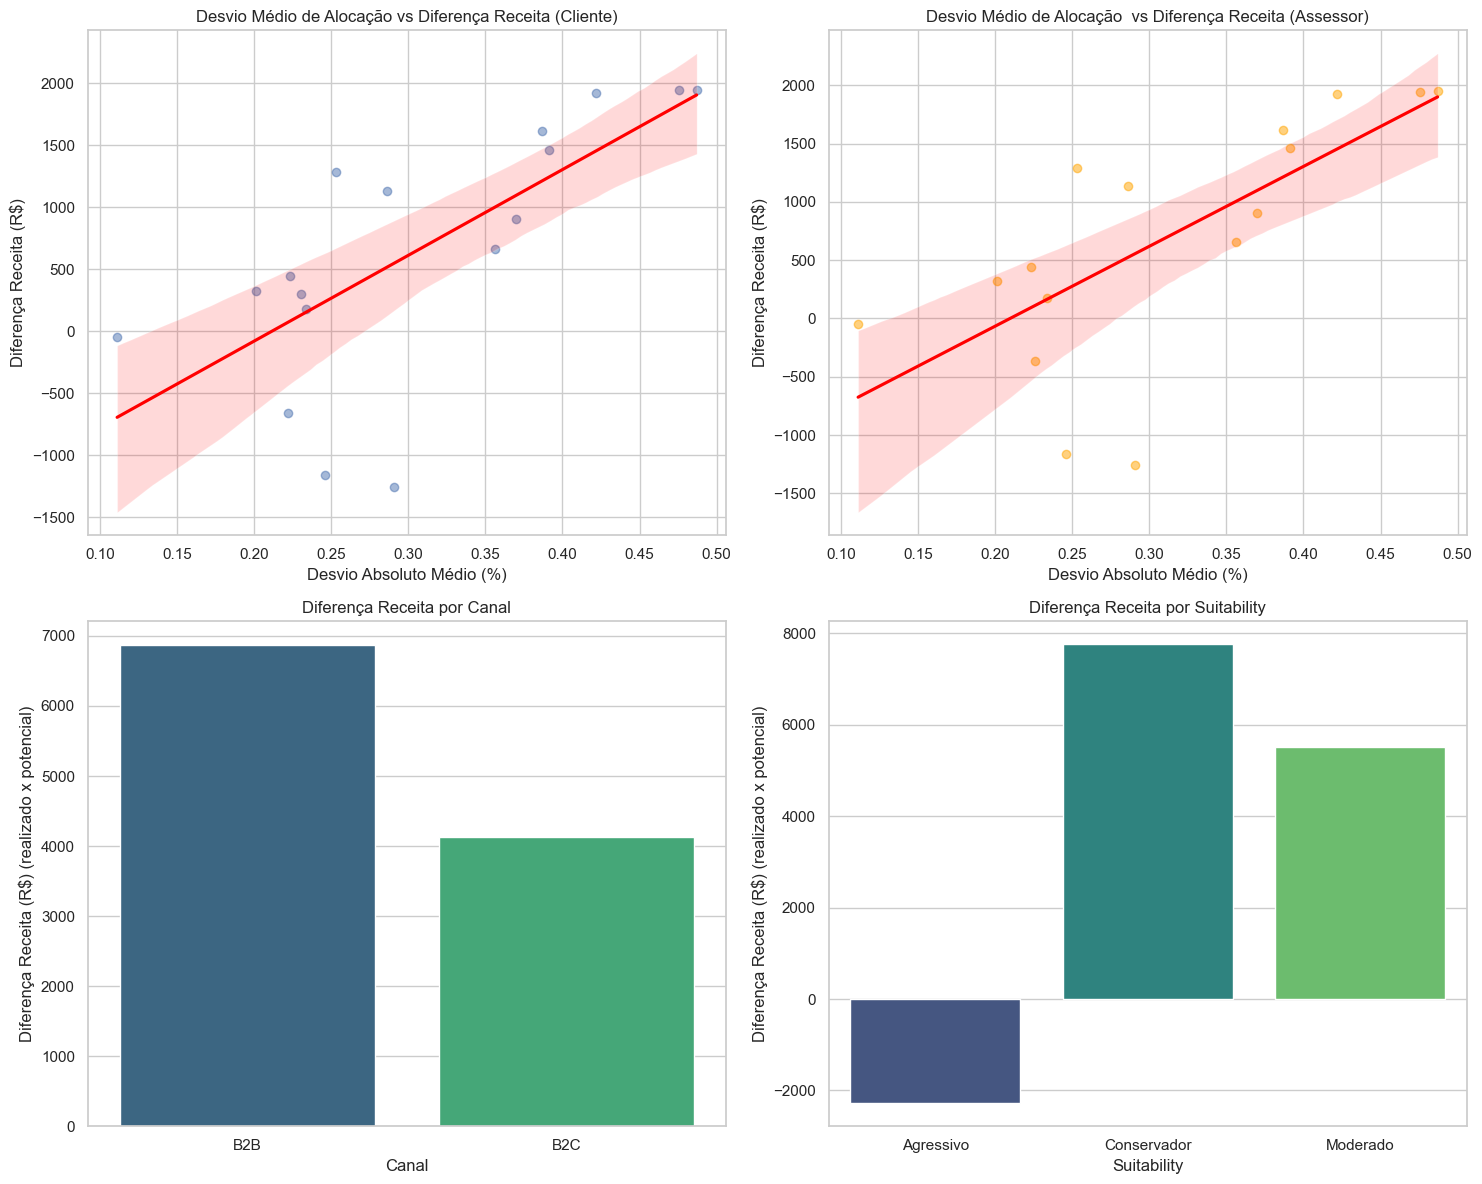

In [ ]:
sns.set(style="whitegrid")

fig, axs = plt.subplots(2, 2, figsize=(15, 12))  

# --- 1. Agrupar por cliente ---
cliente_group = df.groupby('COD_DIM_CONTA').agg({
    'DESVIO_ABS': 'mean',
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()

cliente_group['DELTA_RECEITA'] = cliente_group['RECEITA_ATUAL'] - cliente_group['RECEITA_POTENCIAL']

# --- 2. Agrupar por assessor ---
assessor_group = df.groupby('COD_DIM_CANAL_ASSESSOR').agg({
    'DESVIO_ABS': 'mean',
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()

assessor_group['DELTA_RECEITA'] = assessor_group['RECEITA_ATUAL'] - assessor_group['RECEITA_POTENCIAL']

# --- Linha 1 --- #
# 1. Cliente
sns.regplot(
    x='DESVIO_ABS', y='DELTA_RECEITA', data=cliente_group,
    scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axs[0, 0]
)
axs[0, 0].set_title('Desvio Médio de Alocação vs Diferença Receita (Cliente)')
axs[0, 0].set_xlabel('Desvio Absoluto Médio (%)')
axs[0, 0].set_ylabel('Diferença Receita (R$)')

# 2. Assessor
sns.regplot(
    x='DESVIO_ABS', y='DELTA_RECEITA', data=assessor_group,
    scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axs[0, 1], color='orange'
)
axs[0, 1].set_title('Desvio Médio de Alocação  vs Diferença Receita (Assessor)')
axs[0, 1].set_xlabel('Desvio Absoluto Médio (%)')
axs[0, 1].set_ylabel('Diferença Receita (R$)')

# --- Linha 2 --- #
# Delta Receita por Canal (sem desvio)
delta_receita_canal = df.groupby('CANAL').agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()
delta_receita_canal['DELTA_RECEITA'] = delta_receita_canal['RECEITA_ATUAL'] - delta_receita_canal['RECEITA_POTENCIAL']

sns.barplot(x='CANAL', y='DELTA_RECEITA', data=delta_receita_canal, ax=axs[1, 0], palette='viridis')
axs[1, 0].set_title('Diferença Receita por Canal')
axs[1, 0].set_ylabel('Diferença Receita (R$)')
axs[1, 0].set_xlabel('Canal')

# Delta Receita por Suitability (sem desvio)
delta_receita_suit = df.groupby('SUITABILITY').agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()
delta_receita_suit['DELTA_RECEITA'] = delta_receita_suit['RECEITA_ATUAL'] - delta_receita_suit['RECEITA_POTENCIAL']

sns.barplot(x='SUITABILITY', y='DELTA_RECEITA', data=delta_receita_suit, ax=axs[1, 1], palette='viridis')
axs[1, 1].set_title('Diferença Receita por Suitability')
axs[1, 1].set_ylabel('Diferença Receita (R$)')
axs[1, 1].set_xlabel('Suitability')

plt.tight_layout()
plt.show()


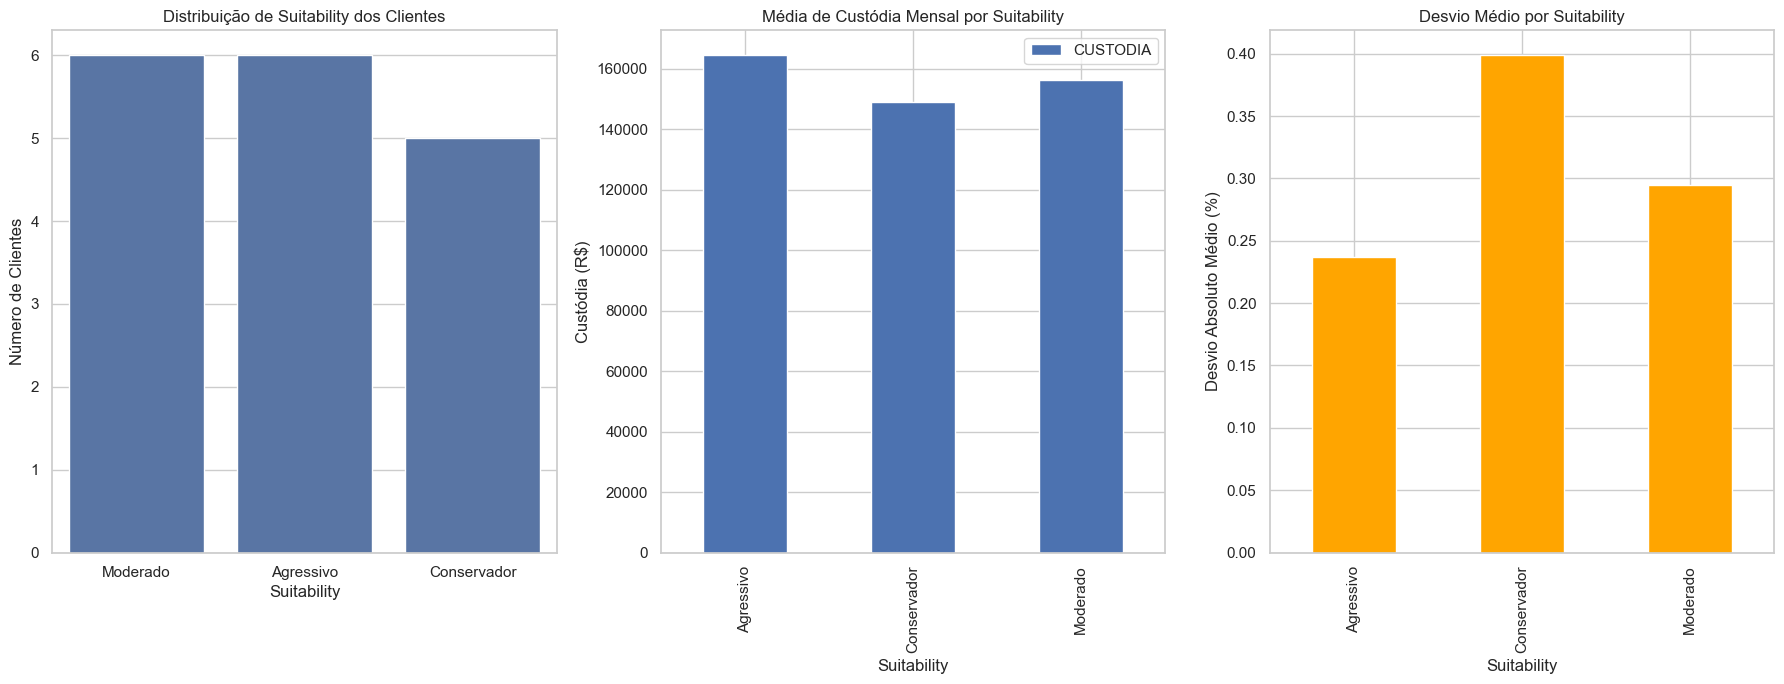

In [162]:
df_grouped = df.groupby(['COD_DIM_CONTA', 'SUITABILITY'], as_index=False)['DESVIO_ABS'].mean()

fig, axs = plt.subplots(1, 3, figsize=(18, 7))

# Gráfico 1 - Distribuição de clientes por perfil (SUITABILITY)
sns.countplot(data=df_grouped, x='SUITABILITY', ax=axs[0])
axs[0].set_title("Distribuição de Suitability dos Clientes")
axs[0].set_xlabel("Suitability")
axs[0].set_ylabel("Número de Clientes")

df_mean_custodia = df[df['CUSTODIA'] >= 0]
custodia_mean = df_mean_custodia.groupby(['COD_DIM_CONTA', 'COD_DIM_TEMPO','SUITABILITY'])['CUSTODIA'].sum().reset_index()
custodia_mean = custodia_mean.groupby('SUITABILITY')['CUSTODIA'].mean().reset_index()
custodia_mean.plot(kind='bar', x='SUITABILITY', y='CUSTODIA', ax=axs[1])
axs[1].set_title("Média de Custódia Mensal por Suitability")
axs[1].set_xlabel("Suitability")
axs[1].set_ylabel("Custódia (R$)")

desvio_medio = df_grouped.groupby('SUITABILITY')['DESVIO_ABS'].mean()
desvio_medio.plot(kind='bar', ax=axs[2], color='orange')
axs[2].set_title("Desvio Médio por Suitability")
axs[2].set_xlabel("Suitability")
axs[2].set_ylabel("Desvio Absoluto Médio (%)")

plt.tight_layout()
plt.show()


---

### Insight 3. Explorando clientes agressivos (com receita atual menor que potencial)

Clientes classificados como agressivos apresentam receitas atuais abaixo do potencial, mesmo sendo os que mais alocam em média.

Ao investigar, identificamos uma superexposição à estratégia pós-fixada, que dilui o retorno geral da carteira e subaproveita o potencial de estratégias como internacional e renda variável, que o perfil aceita

Dentro deste cenário, existe uma oportunidade clara de revisão do portfólio desses clientes, direcionando-os para estratégias como internacional e renda variável, historicamente associadas a maior retorno e compatíveis com o perfil identificado.

In [164]:
receita_conta = df.groupby(['COD_DIM_CONTA', 'SUITABILITY'])[['RECEITA_ATUAL', 'RECEITA_POTENCIAL']].sum().reset_index()

conta_potencial_maior = receita_conta[
    receita_conta['RECEITA_POTENCIAL'] > receita_conta['RECEITA_ATUAL']
]
conta_potencial_maior

,COD_DIM_CONTA,SUITABILITY,RECEITA_ATUAL,RECEITA_POTENCIAL
2,23,Agressivo,3152.815063,3812.019374
6,87,Agressivo,3535.270041,4697.795459
13,126,Agressivo,2454.120644,3710.409292
16,144,Moderado,1808.865739,1859.216558


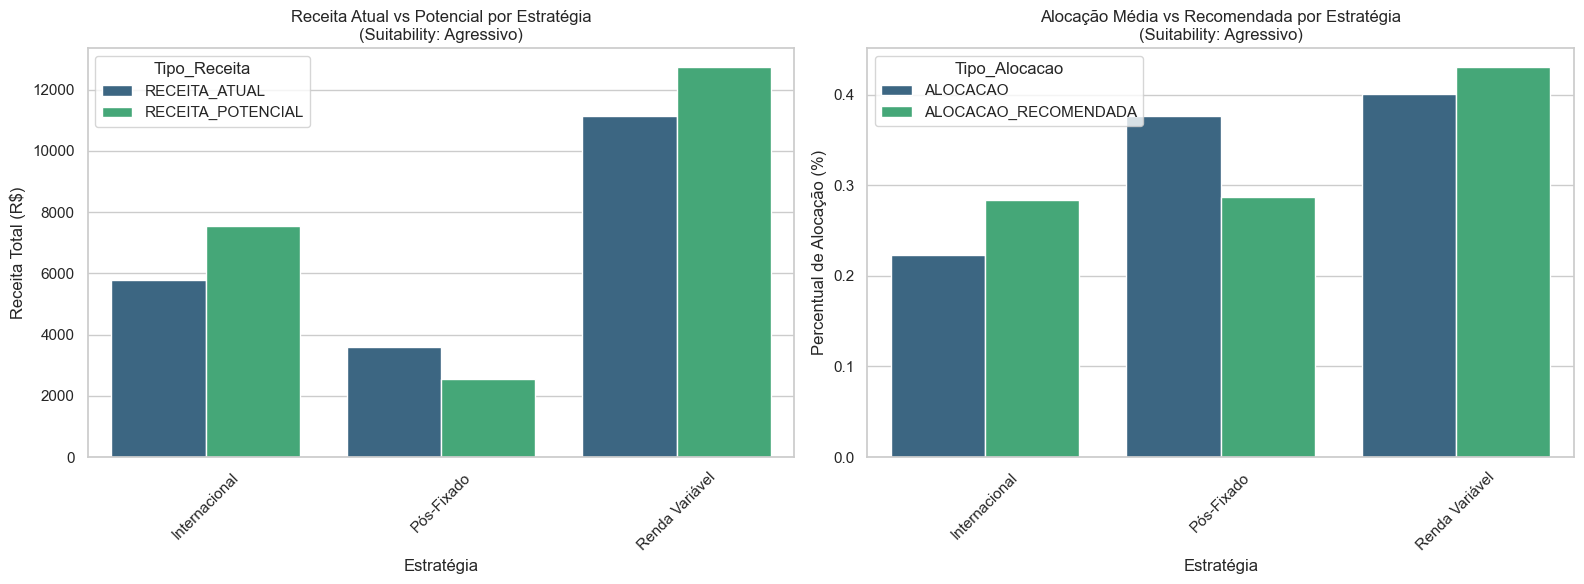

In [ ]:
# Agrupar por conta, suitability e estratégia
df_estrategia_agressivo = df.groupby(['COD_DIM_CONTA', 'SUITABILITY', 'ESTRATEGIA'], as_index=False).agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
})

# Calcular a diferença
df_estrategia_agressivo['DELTA_RECEITA'] = df_estrategia_agressivo['RECEITA_ATUAL'] - df_estrategia_agressivo['RECEITA_POTENCIAL']

# Filtrar apenas suitability agressivo
df_estrategia_agressivo = df_estrategia_agressivo[df_estrategia_agressivo['SUITABILITY'] == 'Agressivo']


# Agrupar receitas por estratégia (já filtrado por 'Agressivo')
df_plot_estrategia = df_estrategia_agressivo.groupby('ESTRATEGIA').agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()

df_plot_melted_receita = df_plot_estrategia.melt(
    id_vars='ESTRATEGIA',
    value_vars=['RECEITA_ATUAL', 'RECEITA_POTENCIAL'],
    var_name='Tipo_Receita',
    value_name='Valor'
)

# -- 2. Alocação vs Recomendada (média por estratégia) --

# Filtrar o DataFrame original para apenas Agressivo
df_agressivo = df[df['SUITABILITY'] == 'Agressivo']

# Calcular média das alocações por estratégia
df_plot_alocacao = df_agressivo.groupby('ESTRATEGIA').agg({
    'ALOCACAO': 'mean',
    'ALOCACAO_RECOMENDADA': 'mean'
}).reset_index()

df_plot_melted_aloc = df_plot_alocacao.melt(
    id_vars='ESTRATEGIA',
    value_vars=['ALOCACAO', 'ALOCACAO_RECOMENDADA'],
    var_name='Tipo_Alocacao',
    value_name='Valor'
)

# -- Plotar os dois gráficos lado a lado --

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 - Receita
sns.barplot(data=df_plot_melted_receita, x='ESTRATEGIA', y='Valor', hue='Tipo_Receita', palette='viridis', ax=axs[0])
axs[0].set_title('Receita Atual vs Potencial por Estratégia\n(Suitability: Agressivo)')
axs[0].set_xlabel('Estratégia')
axs[0].set_ylabel('Receita Total (R$)')
axs[0].tick_params(axis='x', rotation=45)

# Gráfico 2 - Alocação
sns.barplot(data=df_plot_melted_aloc, x='ESTRATEGIA', y='Valor', hue='Tipo_Alocacao', palette='viridis', ax=axs[1])
axs[1].set_title('Alocação Média vs Recomendada por Estratégia\n(Suitability: Agressivo)')
axs[1].set_xlabel('Estratégia')
axs[1].set_ylabel('Percentual de Alocação (%)')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---

## Desenvolvimento completo (EDA em Python) - Desafio 4

Abaixo, segue o desenvolvimento e etapas da análise realizada; 

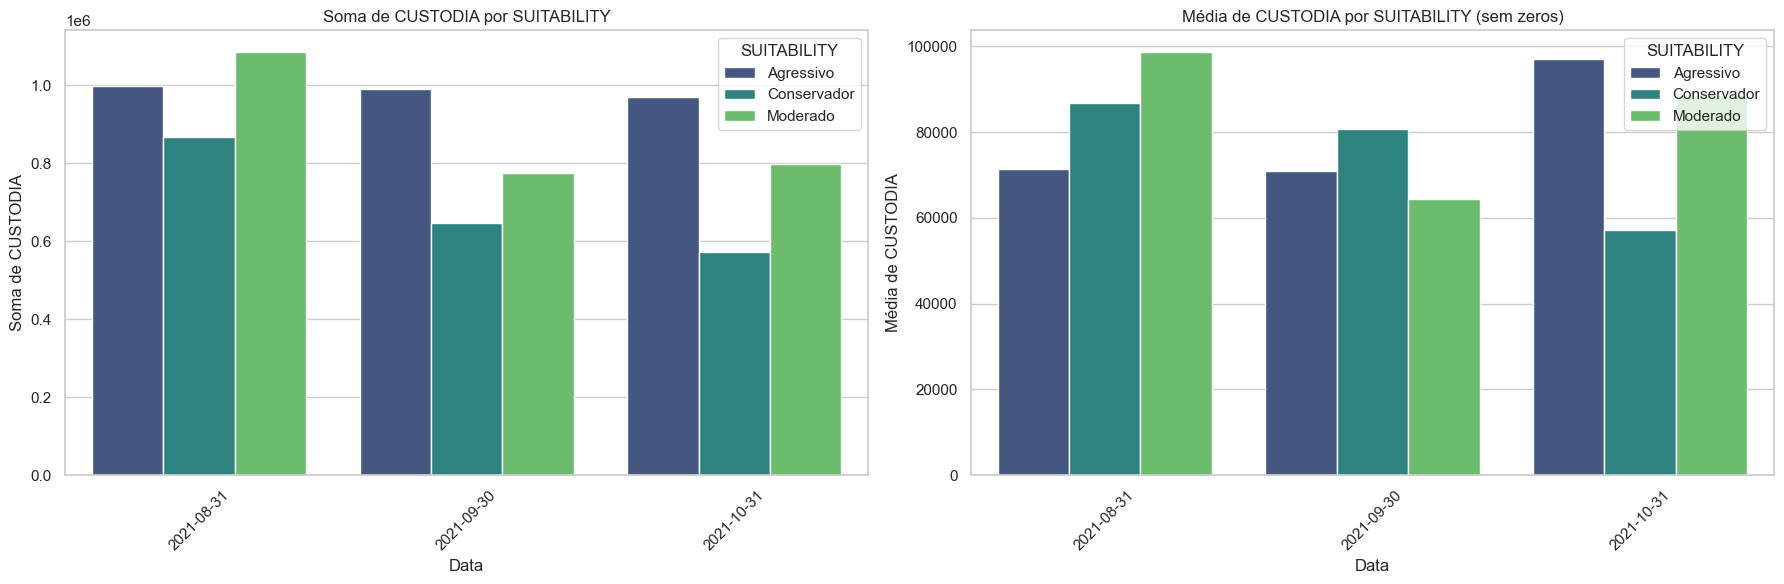

In [153]:
# Soma e Média 

grouped_sum = df.groupby(['COD_DIM_TEMPO', 'SUITABILITY'])['CUSTODIA'].sum().reset_index()

df_filtrado = df[df['CUSTODIA'] >= 0]

grouped_mean = df_filtrado.groupby(['COD_DIM_TEMPO', 'SUITABILITY'])['CUSTODIA'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

sns.barplot(data=grouped_sum, x='COD_DIM_TEMPO', y='CUSTODIA', hue='SUITABILITY', palette='viridis', ax=axes[0])
axes[0].set_title('Soma de CUSTODIA por SUITABILITY')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Soma de CUSTODIA')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=grouped_mean, x='COD_DIM_TEMPO', y='CUSTODIA', hue='SUITABILITY', palette='viridis', ax=axes[1])
axes[1].set_title('Média de CUSTODIA por SUITABILITY (sem zeros)')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Média de CUSTODIA')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


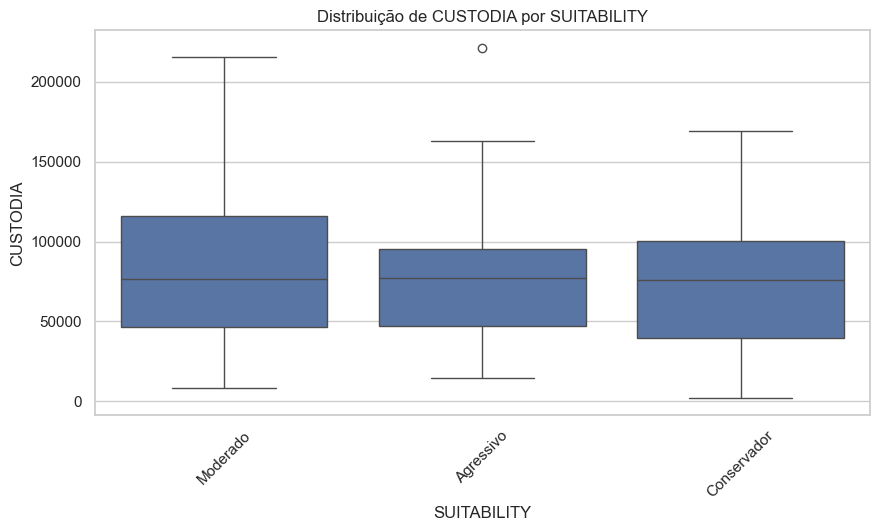

In [138]:
# Boxplot de custódia por SUITABILITY
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['CUSTODIA'] > 0], x='SUITABILITY', y='CUSTODIA')
plt.title('Distribuição de CUSTODIA por SUITABILITY')
plt.xticks(rotation=45)
plt.show()

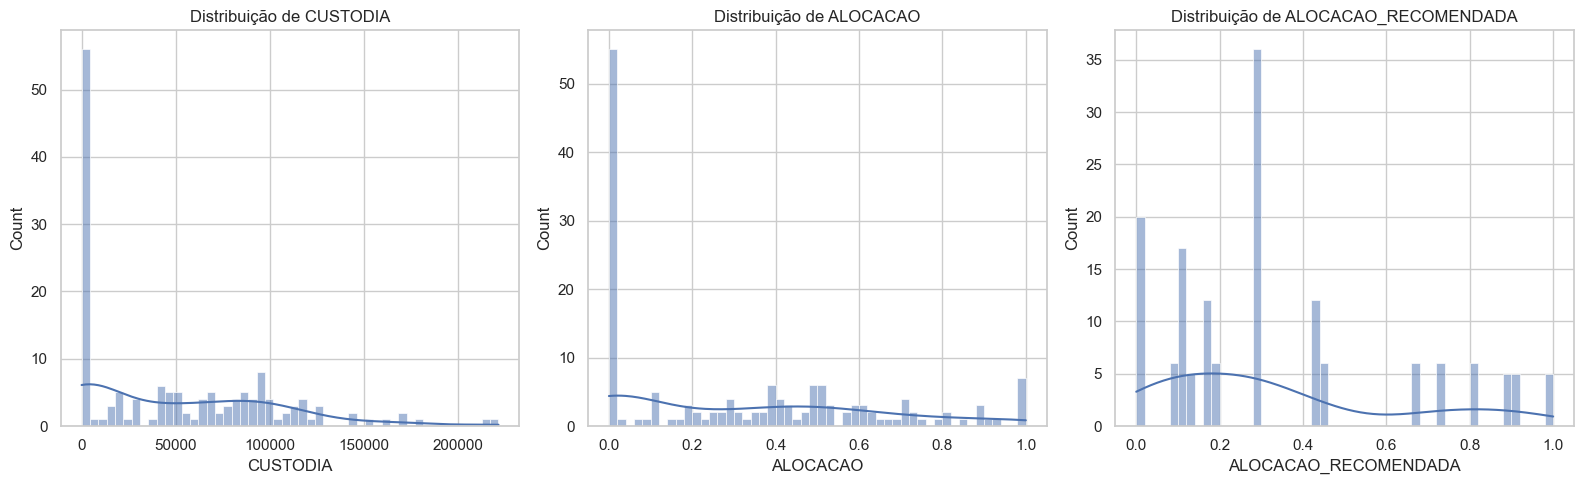

In [139]:
# Distribuição de variáveis numéricas
plt.figure(figsize=(16, 5))
for i, col in enumerate(['CUSTODIA', 'ALOCACAO', 'ALOCACAO_RECOMENDADA']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

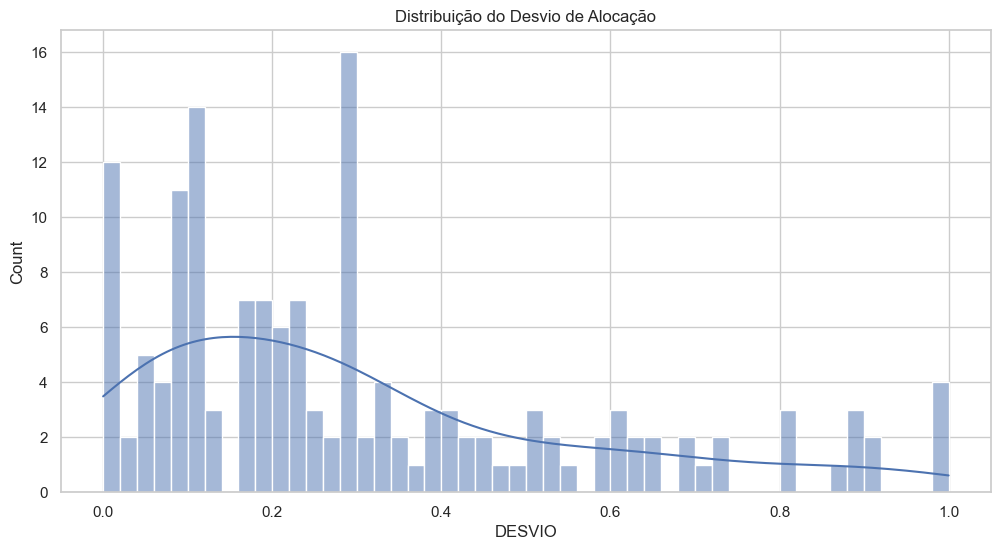

In [140]:
# Desvio de alocação
df['DESVIO'] = np.abs(df['ALOCACAO'] - df['ALOCACAO_RECOMENDADA'])
sns.histplot(df['DESVIO'], bins=50, kde=True)
plt.title('Distribuição do Desvio de Alocação')
plt.show()


   SUITABILITY       CUSTODIA
0    Agressivo  164449.498333
1  Conservador  149058.242143
2     Moderado  156373.472353


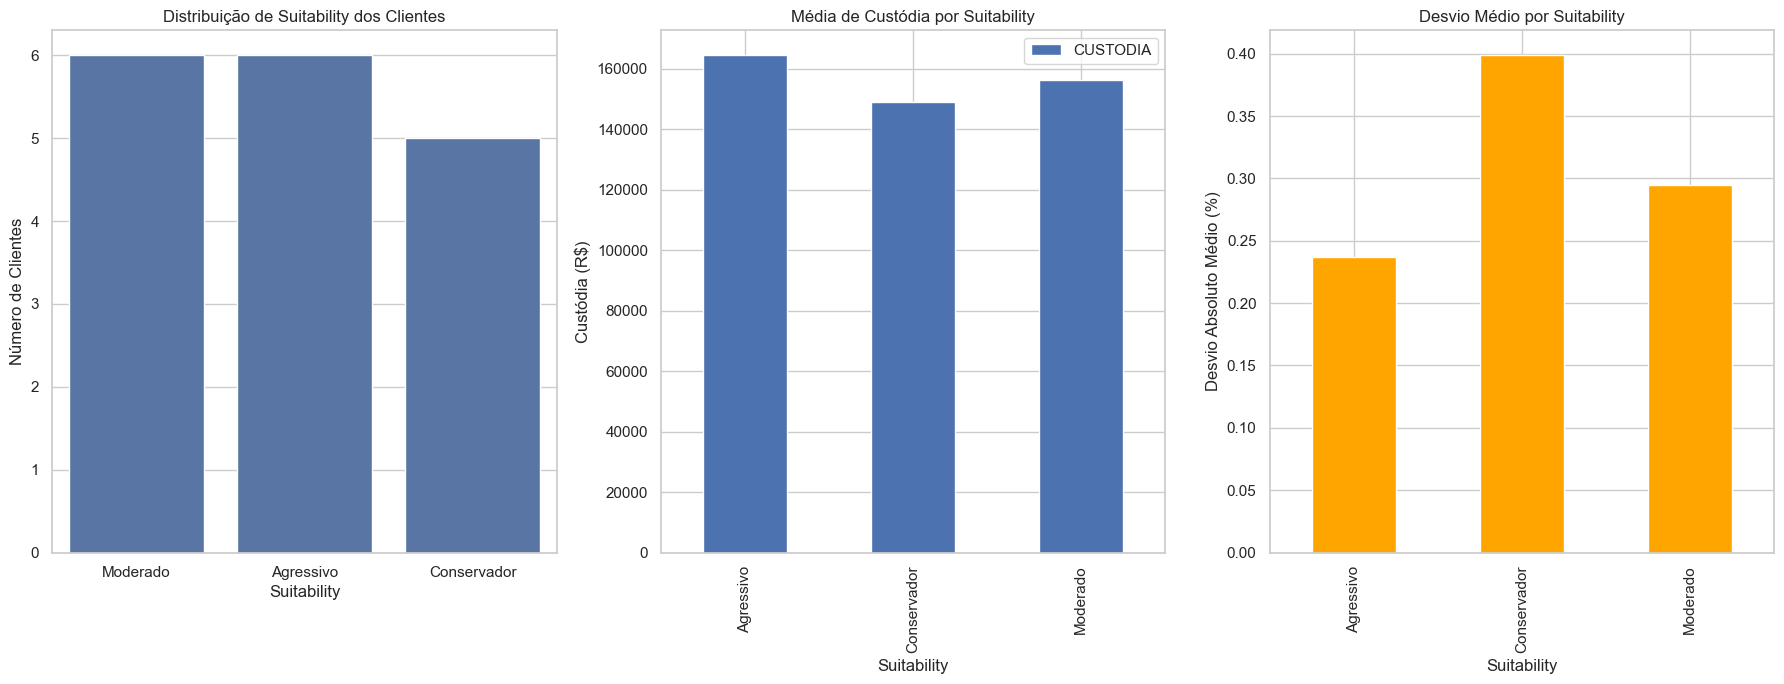

In [ ]:
df_grouped = df.groupby(['COD_DIM_CONTA', 'SUITABILITY'], as_index=False)['DESVIO_ABS'].mean()

fig, axs = plt.subplots(1, 3, figsize=(18, 7))

# Gráfico 1 - Distribuição de clientes por perfil (SUITABILITY)
sns.countplot(data=df_grouped, x='SUITABILITY', ax=axs[0])
axs[0].set_title("Distribuição de Suitability dos Clientes")
axs[0].set_xlabel("Suitability")
axs[0].set_ylabel("Número de Clientes")

df_mean_custodia = df[df['CUSTODIA'] >= 0]

# Média de custódia por conta, tempo e suitability
custodia_mean = df_mean_custodia.groupby(['COD_DIM_CONTA', 'COD_DIM_TEMPO','SUITABILITY'])['CUSTODIA'].sum().reset_index()

# Média final por suitability
custodia_mean = custodia_mean.groupby('SUITABILITY')['CUSTODIA'].mean().reset_index()

print(custodia_mean)

# Plot
custodia_mean.plot(kind='bar', x='SUITABILITY', y='CUSTODIA', ax=axs[1])
axs[1].set_title("Média de Custódia por Suitability")
axs[1].set_xlabel("Suitability")
axs[1].set_ylabel("Custódia (R$)")

desvio_medio = df_grouped.groupby('SUITABILITY')['DESVIO_ABS'].mean()
desvio_medio.plot(kind='bar', ax=axs[2], color='orange')
axs[2].set_title("Desvio Médio por Suitability")
axs[2].set_xlabel("Suitability")
axs[2].set_ylabel("Desvio Absoluto Médio (%)")

plt.tight_layout()
plt.show()


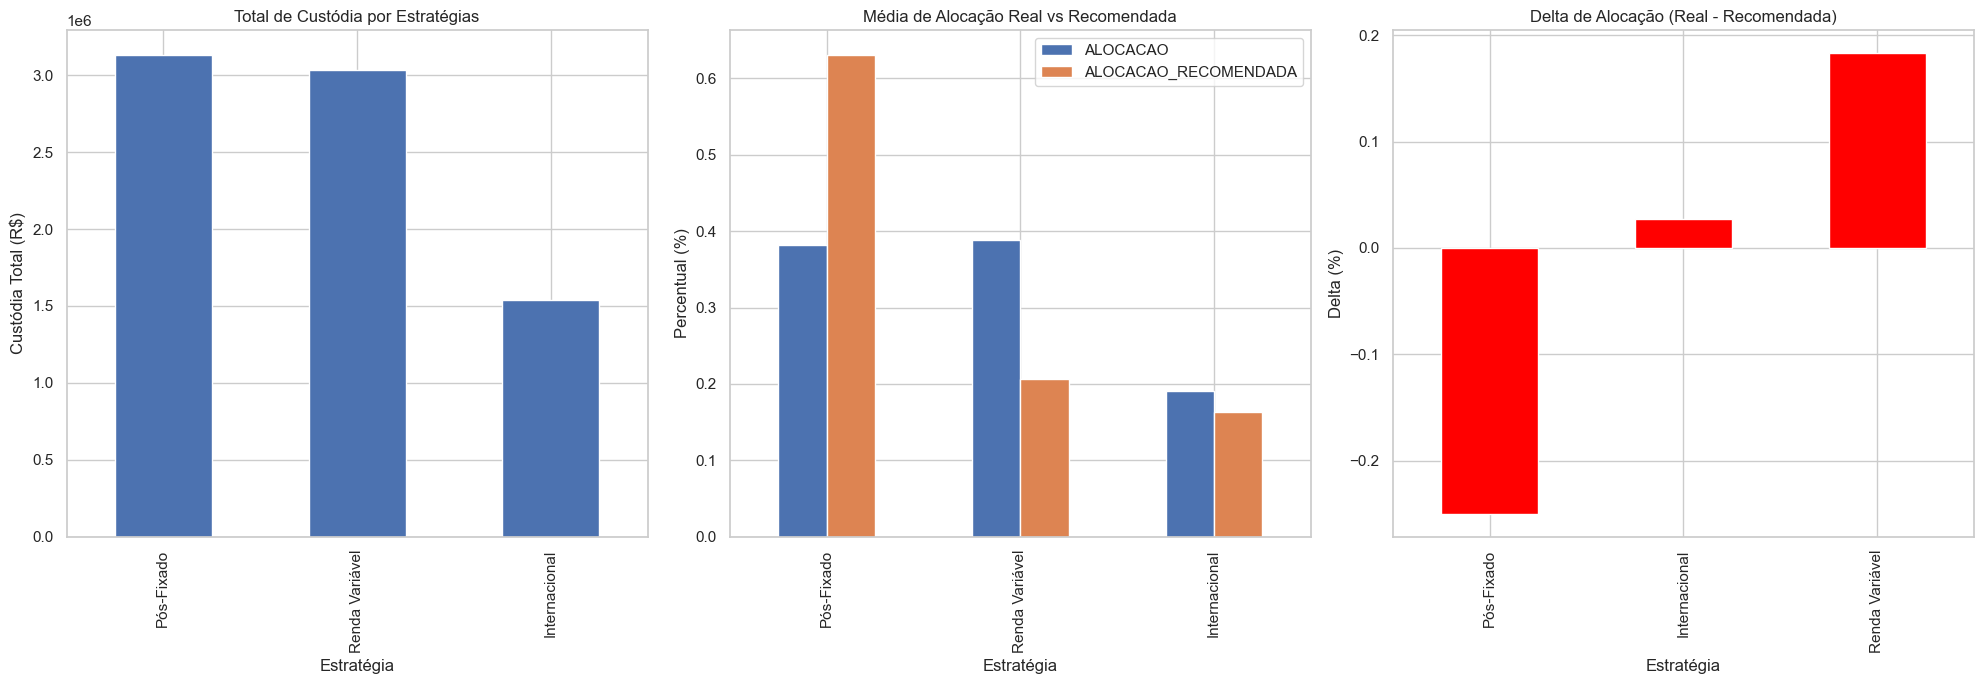

In [ ]:
# Preparar dados
top_estrategias = df.groupby('ESTRATEGIA')['CUSTODIA'].sum().sort_values(ascending=False).head(10)

estrategia_aloc = df.groupby('ESTRATEGIA')[['ALOCACAO', 'ALOCACAO_RECOMENDADA']].mean()
estrategia_aloc = estrategia_aloc.sort_values(by='ALOCACAO_RECOMENDADA', ascending=False)
estrategia_aloc['DELTA'] = estrategia_aloc['ALOCACAO'] - estrategia_aloc['ALOCACAO_RECOMENDADA']

fig, axs = plt.subplots(1, 3, figsize=(20, 7))

top_estrategias.plot(kind='bar', ax=axs[0])
axs[0].set_title("Total de Custódia por Estratégias")
axs[0].set_ylabel("Custódia Total (R$)")
axs[0].set_xlabel("Estratégia")

estrategia_aloc[['ALOCACAO', 'ALOCACAO_RECOMENDADA']].plot(kind='bar', ax=axs[1])
axs[1].set_title("Média de Alocação Real vs Recomendada")
axs[1].set_ylabel("Percentual (%)")
axs[1].set_xlabel("Estratégia")

estrategia_aloc['DELTA'].sort_values().plot(kind='bar', color='red', ax=axs[2])
axs[2].set_title("Delta de Alocação (Real - Recomendada)")
axs[2].set_ylabel("Delta (%)")
axs[2].set_xlabel("Estratégia")

plt.tight_layout()
plt.show()


C:\Users\lucas.souza\AppData\Local\Temp\ipykernel_10188\3482696614.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('viridis', 2)


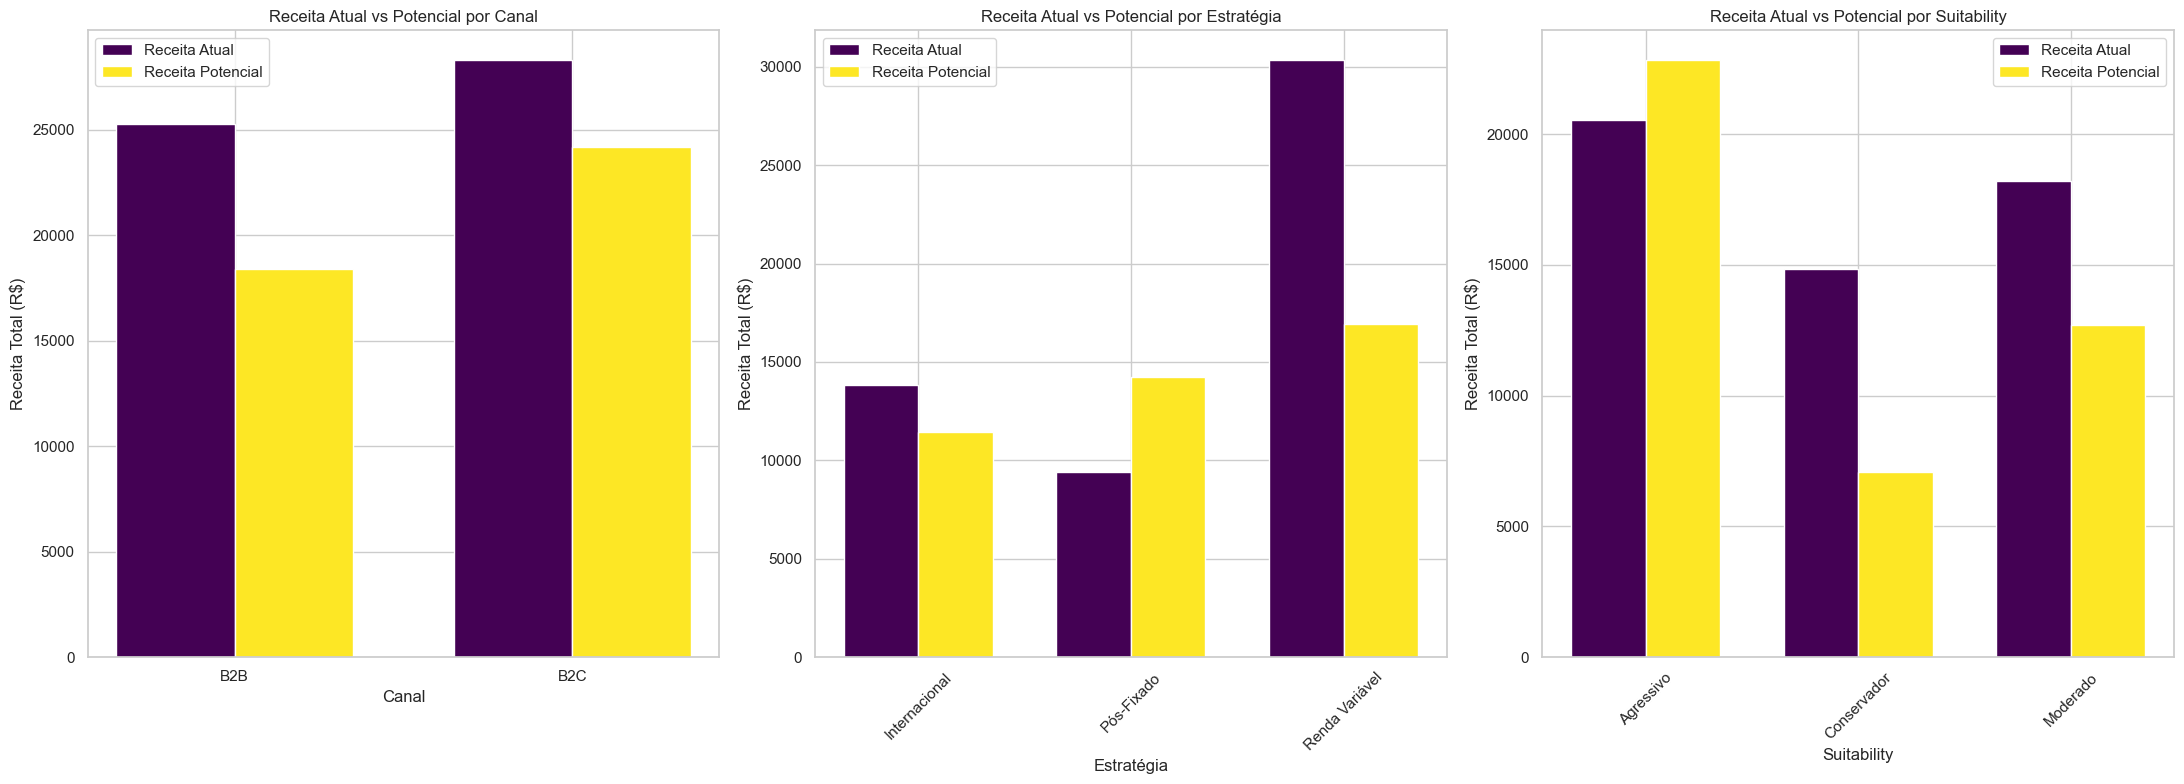

In [144]:
df_receita = df.groupby(
    ['COD_DIM_CONTA', 'COD_DIM_TEMPO', 'CANAL', 'ESTRATEGIA', 'SUITABILITY'],
    as_index=False
)[['RECEITA_ATUAL', 'RECEITA_POTENCIAL']].sum()

# Agrupação para cada dimensão
receita_por_canal = df_receita.groupby('CANAL')[['RECEITA_ATUAL', 'RECEITA_POTENCIAL']].sum()
receita_por_estrategia = df_receita.groupby('ESTRATEGIA')[['RECEITA_ATUAL', 'RECEITA_POTENCIAL']].sum()
receita_por_suit = df_receita.groupby('SUITABILITY')[['RECEITA_ATUAL', 'RECEITA_POTENCIAL']].sum()


palette = cm.get_cmap('viridis', 2)

fig, axs = plt.subplots(1, 3, figsize=(22, 8))

def plot_bar_com_viridis(ax, df_grouped, title, xlabel):
    indices = np.arange(len(df_grouped))
    width = 0.35
    
    ax.bar(indices - width/2, df_grouped['RECEITA_ATUAL'], width, color=palette(0))
    ax.bar(indices + width/2, df_grouped['RECEITA_POTENCIAL'], width, color=palette(1))
    
    ax.set_xticks(indices)
    ax.set_xticklabels(df_grouped.index, rotation=45 if len(df_grouped.index) > 2 else 0)
    ax.set_title(title)
    ax.set_ylabel("Receita Total (R$)")
    ax.set_xlabel(xlabel)
    ax.legend(['Receita Atual', 'Receita Potencial'])

plot_bar_com_viridis(axs[0], receita_por_canal, "Receita Atual vs Potencial por Canal", "Canal")
plot_bar_com_viridis(axs[1], receita_por_estrategia, "Receita Atual vs Potencial por Estratégia", "Estratégia")
plot_bar_com_viridis(axs[2], receita_por_suit, "Receita Atual vs Potencial por Suitability", "Suitability")

plt.tight_layout()
plt.show()

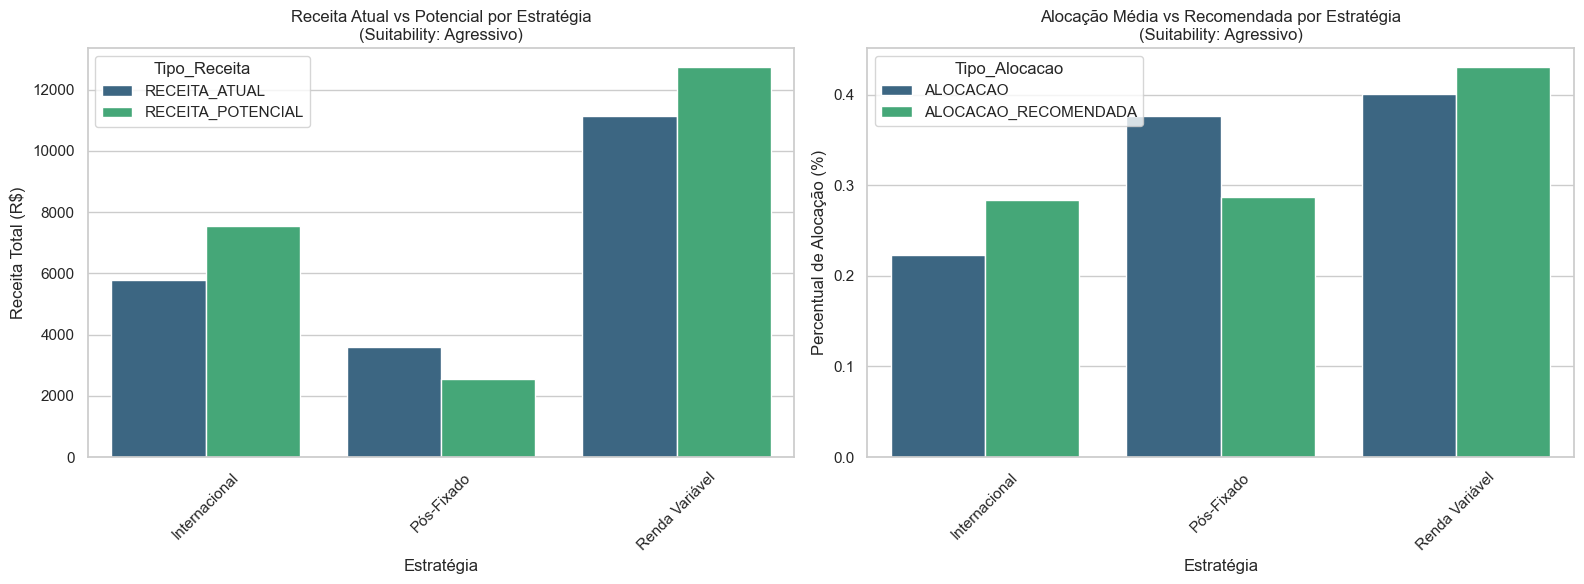

In [ ]:
# Agrupar por conta, suitability e estratégia
df_estrategia_agressivo = df.groupby(['COD_DIM_CONTA', 'SUITABILITY', 'ESTRATEGIA'], as_index=False).agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
})

df_estrategia_agressivo['DELTA_RECEITA'] = df_estrategia_agressivo['RECEITA_ATUAL'] - df_estrategia_agressivo['RECEITA_POTENCIAL']

df_estrategia_agressivo = df_estrategia_agressivo[df_estrategia_agressivo['SUITABILITY'] == 'Agressivo']


df_plot_estrategia = df_estrategia_agressivo.groupby('ESTRATEGIA').agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()

df_plot_melted_receita = df_plot_estrategia.melt(
    id_vars='ESTRATEGIA',
    value_vars=['RECEITA_ATUAL', 'RECEITA_POTENCIAL'],
    var_name='Tipo_Receita',
    value_name='Valor'
)


df_agressivo = df[df['SUITABILITY'] == 'Agressivo']

df_plot_alocacao = df_agressivo.groupby('ESTRATEGIA').agg({
    'ALOCACAO': 'mean',
    'ALOCACAO_RECOMENDADA': 'mean'
}).reset_index()

df_plot_melted_aloc = df_plot_alocacao.melt(
    id_vars='ESTRATEGIA',
    value_vars=['ALOCACAO', 'ALOCACAO_RECOMENDADA'],
    var_name='Tipo_Alocacao',
    value_name='Valor'
)

# -- Plotar os dois gráficos lado a lado --

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 - Receita
sns.barplot(data=df_plot_melted_receita, x='ESTRATEGIA', y='Valor', hue='Tipo_Receita', palette='viridis', ax=axs[0])
axs[0].set_title('Receita Atual vs Potencial por Estratégia\n(Suitability: Agressivo)')
axs[0].set_xlabel('Estratégia')
axs[0].set_ylabel('Receita Total (R$)')
axs[0].tick_params(axis='x', rotation=45)

# Gráfico 2 - Alocação
sns.barplot(data=df_plot_melted_aloc, x='ESTRATEGIA', y='Valor', hue='Tipo_Alocacao', palette='viridis', ax=axs[1])
axs[1].set_title('Alocação Média vs Recomendada por Estratégia\n(Suitability: Agressivo)')
axs[1].set_xlabel('Estratégia')
axs[1].set_ylabel('Percentual de Alocação (%)')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [146]:
# Agrupar por conta e suitability
df_receita_gap = df.groupby(['COD_DIM_CONTA', 'SUITABILITY'], as_index=False).agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
})

# Calcular a diferença
df_receita_gap['DELTA_RECEITA'] = df_receita_gap['RECEITA_ATUAL'] - df_receita_gap['RECEITA_POTENCIAL']

# Exibir as 5 colunas
df_receita_gap[['COD_DIM_CONTA', 'SUITABILITY', 'RECEITA_ATUAL', 'RECEITA_POTENCIAL', 'DELTA_RECEITA']]


,COD_DIM_CONTA,SUITABILITY,RECEITA_ATUAL,RECEITA_POTENCIAL,DELTA_RECEITA
0,13,Moderado,3403.779786,2270.116963,1133.662822
1,15,Moderado,3140.169088,2698.280481,441.888607
2,23,Agressivo,3152.815063,3812.019374,-659.204312
3,40,Conservador,3513.845629,1566.830060,1947.015568
4,74,Agressivo,4517.157114,4338.348756,178.808359
5,81,Agressivo,2965.480097,2641.563970,323.916127
6,87,Agressivo,3535.270041,4697.795459,-1162.525418
7,99,Moderado,2262.277735,1359.178008,903.099727
8,100,Conservador,3015.896442,1729.628239,1286.268203
9,102,Agressivo,3918.913648,3622.546416,296.367232


C:\Users\lucas.souza\AppData\Local\Temp\ipykernel_10188\935100452.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CANAL', y='DELTA_RECEITA', data=delta_receita_canal, ax=axs[1, 0], palette='viridis')
C:\Users\lucas.souza\AppData\Local\Temp\ipykernel_10188\935100452.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SUITABILITY', y='DELTA_RECEITA', data=delta_receita_suit, ax=axs[1, 1], palette='viridis')


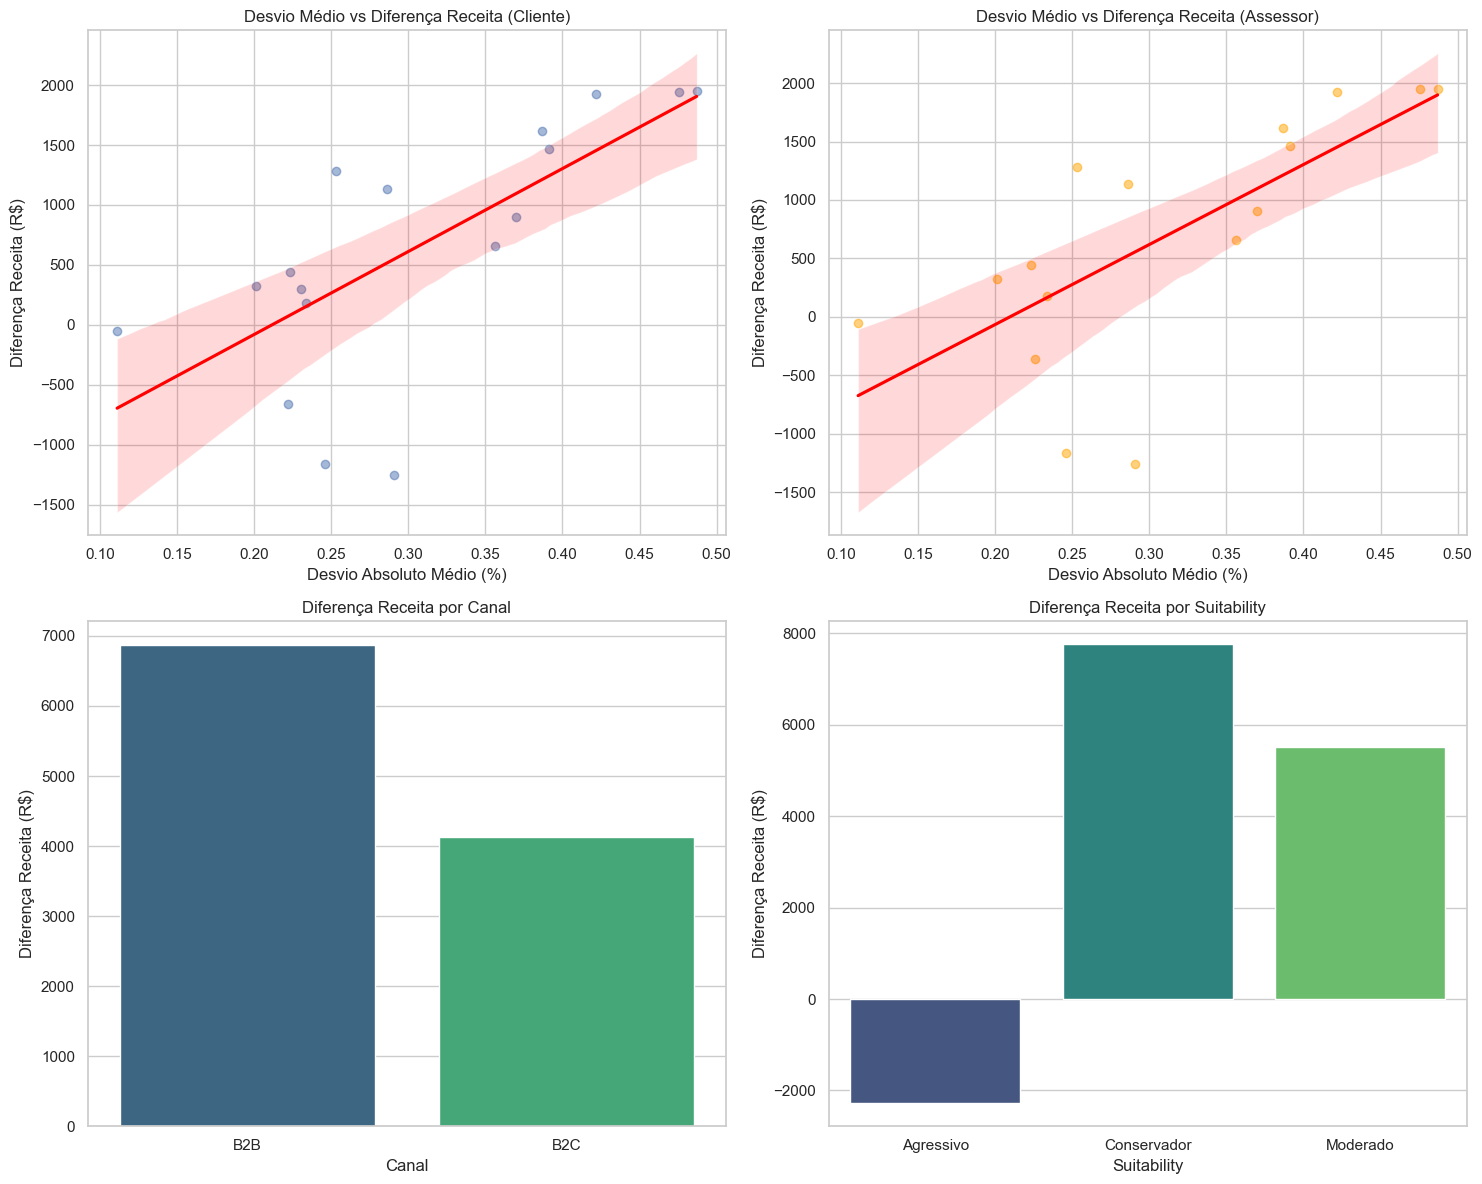

In [ ]:
sns.set(style="whitegrid")

fig, axs = plt.subplots(2, 2, figsize=(15, 12))  

cliente_group = df.groupby('COD_DIM_CONTA').agg({
    'DESVIO_ABS': 'mean',
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()

cliente_group['DELTA_RECEITA'] = cliente_group['RECEITA_ATUAL'] - cliente_group['RECEITA_POTENCIAL']

assessor_group = df.groupby('COD_DIM_CANAL_ASSESSOR').agg({
    'DESVIO_ABS': 'mean',
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()

assessor_group['DELTA_RECEITA'] = assessor_group['RECEITA_ATUAL'] - assessor_group['RECEITA_POTENCIAL']

# --- Linha 1 --- #
# 1. Cliente
sns.regplot(
    x='DESVIO_ABS', y='DELTA_RECEITA', data=cliente_group,
    scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axs[0, 0]
)
axs[0, 0].set_title('Desvio Médio vs Diferença Receita (Cliente)')
axs[0, 0].set_xlabel('Desvio Absoluto Médio (%)')
axs[0, 0].set_ylabel('Diferença Receita (R$)')

# 2. Assessor
sns.regplot(
    x='DESVIO_ABS', y='DELTA_RECEITA', data=assessor_group,
    scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axs[0, 1], color='orange'
)
axs[0, 1].set_title('Desvio Médio vs Diferença Receita (Assessor)')
axs[0, 1].set_xlabel('Desvio Absoluto Médio (%)')
axs[0, 1].set_ylabel('Diferença Receita (R$)')

# --- Linha 2 --- #
# Delta Receita por Canal (sem desvio)
delta_receita_canal = df.groupby('CANAL').agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()
delta_receita_canal['DELTA_RECEITA'] = delta_receita_canal['RECEITA_ATUAL'] - delta_receita_canal['RECEITA_POTENCIAL']

sns.barplot(x='CANAL', y='DELTA_RECEITA', data=delta_receita_canal, ax=axs[1, 0], palette='viridis')
axs[1, 0].set_title('Diferença Receita por Canal')
axs[1, 0].set_ylabel('Diferença Receita (R$)')
axs[1, 0].set_xlabel('Canal')

# Delta Receita por Suitability (sem desvio)
delta_receita_suit = df.groupby('SUITABILITY').agg({
    'RECEITA_ATUAL': 'sum',
    'RECEITA_POTENCIAL': 'sum'
}).reset_index()
delta_receita_suit['DELTA_RECEITA'] = delta_receita_suit['RECEITA_ATUAL'] - delta_receita_suit['RECEITA_POTENCIAL']

sns.barplot(x='SUITABILITY', y='DELTA_RECEITA', data=delta_receita_suit, ax=axs[1, 1], palette='viridis')
axs[1, 1].set_title('Diferença Receita por Suitability')
axs[1, 1].set_ylabel('Diferença Receita (R$)')
axs[1, 1].set_xlabel('Suitability')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df['DESVIO_ABS'] = abs(df['ALOCACAO'] - df['ALOCACAO_RECOMENDADA'])

soma_desvios = df.groupby('COD_DIM_CANAL_ASSESSOR')['DESVIO_ABS'].sum().rename('SOMA_DESVIOS')

clientes_unicos = df.groupby('COD_DIM_CANAL_ASSESSOR')['COD_DIM_CONTA'].nunique().rename('CLIENTES_UNICOS')

desvio_ponderado = (soma_desvios / clientes_unicos).rename('DESVIO_PONDERADO')

df_filtrado = df[df['CUSTODIA'] >= 0].copy()

custodia_mensal_assessor = (
    df_filtrado
    .groupby(['COD_DIM_CANAL_ASSESSOR', 'COD_DIM_TEMPO'])['CUSTODIA']
    .sum()
    .groupby('COD_DIM_CANAL_ASSESSOR')
    .mean()
    .rename('CUSTODIA_MENSAL_MEDIA')
)

receita_atual_mensal_assessor = (
    df_filtrado
    .groupby(['COD_DIM_CANAL_ASSESSOR', 'COD_DIM_TEMPO'])['RECEITA_ATUAL']
    .sum()
    .groupby('COD_DIM_CANAL_ASSESSOR')
    .mean()
    .rename('RECEITA_ATUAL_MENSAL_MEDIA')
)

receita_potencial_mensal_assessor = (
    df_filtrado
    .groupby(['COD_DIM_CANAL_ASSESSOR', 'COD_DIM_TEMPO'])['RECEITA_POTENCIAL']
    .sum()
    .groupby('COD_DIM_CANAL_ASSESSOR')
    .mean()
    .rename('RECEITA_POTENCIAL_MENSAL_MEDIA')
)

ranking_df = pd.concat([
    desvio_ponderado,
    clientes_unicos,
    custodia_mensal_assessor,
    receita_atual_mensal_assessor,
    receita_potencial_mensal_assessor
], axis=1).dropna()

ranking_df['CUSTODIA_MENSAL_MEDIA_POR_CLIENTE'] = (
    ranking_df['CUSTODIA_MENSAL_MEDIA'] / ranking_df['CLIENTES_UNICOS']
)
ranking_df['RECEITA_ATUAL_MENSAL_POR_CLIENTE'] = (
    ranking_df['RECEITA_ATUAL_MENSAL_MEDIA'] / ranking_df['CLIENTES_UNICOS']
)
ranking_df['RECEITA_POTENCIAL_MENSAL_POR_CLIENTE'] = (
    ranking_df['RECEITA_POTENCIAL_MENSAL_MEDIA'] / ranking_df['CLIENTES_UNICOS']
)

ranking_df['VARIACAO_RECEITA'] = (
    ranking_df['RECEITA_ATUAL_MENSAL_POR_CLIENTE'] - ranking_df['RECEITA_POTENCIAL_MENSAL_MEDIA']
)

ranking_df['FATOR_CUSTODIA'] = ranking_df['CUSTODIA_MENSAL_MEDIA_POR_CLIENTE'].mean() / ranking_df['CUSTODIA_MENSAL_MEDIA_POR_CLIENTE']

ranking_df['SCORE'] = (ranking_df['DESVIO_PONDERADO'] ** 2) * ranking_df['FATOR_CUSTODIA']

ranking_df = ranking_df.sort_values(by='SCORE', ascending=True).reset_index()
ranking_df['RANK'] = ranking_df['SCORE'].rank(method='min', ascending=True).astype(int)

cols_exibir = [
    'COD_DIM_CANAL_ASSESSOR',
    'SCORE',
    'RANK',
    'DESVIO_PONDERADO',
    'CUSTODIA_MENSAL_MEDIA',
    'CUSTODIA_MENSAL_MEDIA_POR_CLIENTE',
    'CLIENTES_UNICOS',
    'FATOR_CUSTODIA',
    'RECEITA_ATUAL_MENSAL_MEDIA',
    'RECEITA_POTENCIAL_MENSAL_MEDIA',
    'RECEITA_ATUAL_MENSAL_POR_CLIENTE',
    'RECEITA_POTENCIAL_MENSAL_POR_CLIENTE',
    'VARIACAO_RECEITA'
]

ranking_df[cols_exibir].head(100)

,COD_DIM_CANAL_ASSESSOR,SCORE,RANK,DESVIO_PONDERADO,CUSTODIA_MENSAL_MEDIA,CUSTODIA_MENSAL_MEDIA_POR_CLIENTE,CLIENTES_UNICOS,FATOR_CUSTODIA,RECEITA_ATUAL_MENSAL_MEDIA,RECEITA_POTENCIAL_MENSAL_MEDIA,RECEITA_ATUAL_MENSAL_POR_CLIENTE,RECEITA_POTENCIAL_MENSAL_POR_CLIENTE,VARIACAO_RECEITA
0,28,1.198101,1,1.000112,130135.683333,130135.683333,1,1.197834,602.955246,427.603183,602.955246,427.603183,175.352064
1,9,3.351222,2,2.008697,187680.333333,187680.333333,1,0.830566,1046.723029,702.643500,1046.723029,702.643500,344.079530
2,33,3.671239,3,2.101964,187599.180000,187599.180000,1,0.830926,1505.719038,937.334889,1505.719038,937.334889,568.384149
3,29,3.752394,4,2.211657,203198.413333,203198.413333,1,0.767137,1178.423347,1191.453346,1178.423347,1191.453346,-13.029999
4,45,4.019358,5,2.035678,321428.726667,160714.363333,2,0.969926,2357.242904,1819.915138,1178.621452,909.957569,-641.293686
5,40,4.489360,6,1.812610,114082.126667,114082.126667,1,1.366393,988.493366,698.039958,988.493366,698.039958,290.453407
6,41,4.769784,7,2.278395,169649.476667,169649.476667,1,0.918841,1005.298814,576.542746,1005.298814,576.542746,428.756068
7,53,6.418872,8,2.573658,160855.590000,160855.590000,1,0.969074,1134.593262,442.648013,1134.593262,442.648013,691.945249
8,72,6.662119,9,2.618161,160388.543333,160388.543333,1,0.971896,818.040215,929.512146,818.040215,929.512146,-111.471931
9,39,11.405847,10,3.481309,165634.440000,165634.440000,1,0.941114,1328.918730,528.288479,1328.918730,528.288479,800.630251


In [ ]:
receita_assessor = df.groupby('COD_DIM_CANAL_ASSESSOR')[['RECEITA_ATUAL', 'RECEITA_POTENCIAL']].sum().reset_index()

assessores_potencial_maior = receita_assessor[
    receita_assessor['RECEITA_POTENCIAL'] > receita_assessor['RECEITA_ATUAL']
]

print(f"Assessores com receita potencial maior que a atual: {len(assessores_potencial_maior)}")
assessores_potencial_maior

Assessores com receita potencial maior que a atual: 4


,COD_DIM_CANAL_ASSESSOR,RECEITA_ATUAL,RECEITA_POTENCIAL
3,28,1808.865739,1859.216558
4,29,3535.270041,4697.795459
11,45,7071.728711,7434.565791
14,72,2454.120644,3710.409292


In [ ]:
receita_conta = df.groupby(['COD_DIM_CONTA', 'SUITABILITY'])[['RECEITA_ATUAL', 'RECEITA_POTENCIAL']].sum().reset_index()

conta_potencial_maior = receita_conta[
    receita_conta['RECEITA_POTENCIAL'] > receita_conta['RECEITA_ATUAL']
]
conta_potencial_maior

,COD_DIM_CONTA,SUITABILITY,RECEITA_ATUAL,RECEITA_POTENCIAL
2,23,Agressivo,3152.815063,3812.019374
6,87,Agressivo,3535.270041,4697.795459
13,126,Agressivo,2454.120644,3710.409292
16,144,Moderado,1808.865739,1859.216558


Caso você tenha interesse em aprender mais sobre Python segue alguns materiais que podem te ajudar no futuro:

Python Básico:
- [Introdução Python](https://www.devmedia.com.br/python-tutorial/33274)
- [Como são declaradas variáveis no Python](https://www.devmedia.com.br/python-trabalhando-com-variaveis/38644)
- [Como são criadas funções no Python](https://algoritmosempython.com.br/cursos/programacao-python/funcoes/)
- [Comentários Python](https://acervolima.com/python-pandas-dataframe-round/)
- [Como funciona o try e except no Python](https://www.geeksforgeeks.org/python-try-except/)
- [Como funcionam estruturas condicionais no Python](https://blog.betrybe.com/python/if-else/#:~:text=Uma%20estrutura%20condicional%20na%20linguagem,igual%20a%20zero%2C%20por%20exemplo.)

Pandas:
- [O que é Pandas?](https://medium.com/tech-grupozap/introdu%C3%A7%C3%A3o-a-biblioteca-pandas-89fa8ed4fa38)
- [Criando DataFrames no Pandas](https://www.covildodev.com.br/artigo/criar-dataframes-pandas-python)
- [Como é feito o Join no Pandas](https://medium.com/data-hackers/pandas-combinando-data-frames-com-merge-e-concat-10e7d07ca5ec)
- [Como é feito group by no Pandas](https://www.geeksforgeeks.org/python-pandas-dataframe-groupby/)
- [Como arredondar no Pandas](https://acervolima.com/python-pandas-dataframe-round/)